In [3]:
import pandas as pd

#import files
nodes = pd.read_csv('nba_trade_nodes_MASTER.csv')
raw_interactions = pd.read_csv('nba_trade_raw_interactions.csv')
weighted_edges = pd.read_csv('nba_trade_weighted_edges.csv')

In [4]:
nodes.head()

,User_DID,User_Handle,Post_ID,Text,Date
0,did:plc:u635tkuyerevp54anewhplnk,sportnewws.bsky.social,3mduia5jul52w,\n#All-Star #All-Star Game #Anthony Edward...,2026-02-02T08:59:59.550697+00:00
1,did:plc:zo7ppsdhdrry76iil7lwmflh,lovenba.bsky.social,3mduhwg552r2y,San Antonio Spurs vs Orlando Magic Full Game H...,2026-02-02T08:54:30+00:00
2,did:plc:zo7ppsdhdrry76iil7lwmflh,lovenba.bsky.social,3mduhwoncgx2r,Cleveland Cavaliers vs Portland Trail Blazers ...,2026-02-02T08:54:38+00:00
3,did:plc:gto2mpwuxsudnj7huncxd3ez,rdeck55.bsky.social,3mdui7d7by22t,Worst officiating I’ve seen since the last NBA...,2026-02-02T08:59:32.057Z
4,did:plc:2k6avu5mrlxqqwsfceza2g3w,project-push.tk.gg,3mdui4tfy7b2f,"It’s not the audience, it’s a professional con...",2026-02-02T08:58:01.601Z


In [5]:
#Convert to datetime
nodes["Date"] = pd.to_datetime(nodes["Date"], format='mixed', utc = True)

#Convert from UTC to Eastern Standard Time (5 hours)
nodes["Date_ET"] = nodes["Date"] - pd.Timedelta(hours=5)

**Research Question 1: What is the structural organization of the Bluesky NBA reply network during the trade deadline, and does it exhibit modular community structure and centralized hub formation?**

In [6]:
raw_interactions.head()

,Source_DID,Target_DID,Source_Handle,Target_Handle,Post_ID,Parent_Post_ID
0,did:plc:yecurhb3o7soofp7k3aczs2l,did:plc:dk6vxaa5eww54weaj67ehai2,slwpkrazriguez.bsky.social,blaqdocdown.bsky.social,3mdv2oazyus2g,3mdugp2y5sc25
1,did:plc:uq4efj37tiyykcyla44cxhos,did:plc:dk6vxaa5eww54weaj67ehai2,mrjohnbusiness.bsky.social,blaqdocdown.bsky.social,3mdup4hw4o222,3mdugp2y5sc25
2,did:plc:dk6vxaa5eww54weaj67ehai2,did:plc:uq4efj37tiyykcyla44cxhos,blaqdocdown.bsky.social,mrjohnbusiness.bsky.social,3mduvphzd2k2o,3mdup4hw4o222
3,did:plc:ajqtqsgro4brci3chin5pxvi,did:plc:dqttaqakyjxaizyk4isfk4ap,miguelovic.bsky.social,piratasdelbasket.bsky.social,3mdupeoo2es25,3mdufomb7cs2q
4,did:plc:2qujlilbeotvfgzgnvqpyijd,did:plc:dqttaqakyjxaizyk4isfk4ap,sinmael.bsky.social,piratasdelbasket.bsky.social,3mduyxyvszk2e,3mdufomb7cs2q


In [7]:
weighted_edges.head()

,Source_DID,Target_DID,Weight,Source_Handle,Target_Handle
0,did:plc:225jifwqatcawcqpo2jjmx5h,did:plc:chw77zmiryitfv34m6aavu5b,1,thunderpuppy.bsky.social,caffeinerabbit.bsky.social
1,did:plc:22dmmdkvuirlegbzpkbalz2u,did:plc:baqegknyonql3dppy43lqaeg,1,cdbackslash.bsky.social,harrisongrimm.bsky.social
2,did:plc:22fudzaxnal4ddodzv2o6mwk,did:plc:4qvo7i5qhu73nn24paiss574,1,jmcdonaldsa.bsky.social,artmoreorless.bsky.social
3,did:plc:22fudzaxnal4ddodzv2o6mwk,did:plc:7cncf7vvk7ynv4af3fxqs42d,1,jmcdonaldsa.bsky.social,brews2you.bsky.social
4,did:plc:22fudzaxnal4ddodzv2o6mwk,did:plc:bhw5yjxeuypdonvanjqtvktu,1,jmcdonaldsa.bsky.social,illiniandramsalum.bsky.social


In [8]:
print(len(nodes.Post_ID), 'Posts/Tweets about NBA from 02-02-2026 to 02-07-2026')
print(nodes.User_DID.nunique(), 'Users posting')
print(raw_interactions.shape[0], 'number of replies between users')
print(weighted_edges.shape[0], 'unique edges/replies between unique users.')

36439 Posts/Tweets about NBA from 02-02-2026 to 02-07-2026
8104 Users posting
8617 number of replies between users
6936 unique edges/replies between unique users.


In [9]:
#Posts with the most replies/edges
print('Posts/replies with the most replies/edges:\n', raw_interactions[['Target_Handle', 'Parent_Post_ID']]\
      .value_counts(['Target_Handle', 'Parent_Post_ID'])[:20])

Posts/replies with the most replies/edges:
 Target_Handle                Parent_Post_ID
chrislhayes.bsky.social      3me2pkdyroc2y     80
markjacob.bsky.social        3mdwekilglc2z     74
washingtonstatestandard.com  3me5lkysxak2a     64
chrislhayes.bsky.social      3me4po2rjxc2c     52
shamsbot.bsky.social         3me2juiirpc2g     44
theathletic.com              3mdz644gm3k2i     37
davidbix.bsky.social         3mebzu2lhws2d     32
1robgunther.bsky.social      3me4r5bjis22p     32
parkermolloy.com             3meaf5ovdms2z     31
shamsbot.bsky.social         3me3kid2y6c2p     30
jasonkirk.fyi                3mdvrkxixik2s     26
justinanumudu.bsky.social    3me56h2wpnc2e     26
juliedicaro.bsky.social      3mdvqbkztq22z     24
shamsbot.bsky.social         3mdxzcah4u624     23
tediosa-miss.bsky.social     3mdverfkt4k24     21
parkermolloy.com             3me5uihzihk2m     20
jimowczarski.bsky.social     3mdyt4xovac23     19
johnhollinger.bsky.social    3me2ly7y2rk2m     19
shamsbot.bsk

In [10]:
#Tweets with the most direct responses and they're tweeter
top_twenty_tweets = raw_interactions[['Target_Handle', 'Parent_Post_ID']]\
      .value_counts(['Target_Handle', 'Parent_Post_ID'])[:20].reset_index()
tweet_text = nodes[['Post_ID', 'Text', 'Date_ET']]

# Merge top_twenty_tweets with tweet_text
top_twenty_with_text = top_twenty_tweets.merge(
    tweet_text,
    left_on='Parent_Post_ID',
    right_on='Post_ID',
    how='left'
)

#Make text easier to read
pd.set_option('display.max_colwidth', None)
from google.colab import data_table
data_table.enable_dataframe_formatter()

top_twenty_with_text[['Text', 'Target_Handle', 'Date_ET', 'count']]

,Text,Target_Handle,Date_ET,count
0,Have absolutely no idea who is on what NBA team rn,chrislhayes.bsky.social,2026-02-04 15:26:56.612000+00:00,80
1,Next he’ll be claiming he‘s the No. 1 pick in the NBA Draft.,markjacob.bsky.social,2026-02-02 21:59:31.301000+00:00,74
2,"With the NBA considering a possible expansion, Washington Gov. Bob Ferguson met Thursday with the league’s commissioner to offer assistance in returning the SuperSonics to Seattle. washingtonstatestandard.com/briefs/washi...",washingtonstatestandard.com,2026-02-05 18:53:42.691000+00:00,64
3,The Chicago Bulls are now composed entirely of guards and second round picks. I don't get it.,chrislhayes.bsky.social,2026-02-05 10:34:20.632000+00:00,52
4,"BREAKING: The Dallas Mavericks are trading 10-time NBA All-Star Anthony Davis, Jaden Hardy, D'Angelo Russell and Dante Exum to the Washington Wizards for Khris Middleton, AJ Johnson, Malaki Branham, Marvin Bagley III, 2 first-round picks and 3 second-rounders, sources tell ESPN.",shamsbot.bsky.social,2026-02-04 13:45:14.425000+00:00,44
5,"A Utah lawmaker has introduced legislation that would allow concealed firearms permit holders to bring guns into publicly funded venues such as the Delta Center, where the Utah Jazz and Utah Mammoth play home games in Salt Lake City.",theathletic.com,2026-02-04 00:42:05.564000+00:00,37
6,"""...this chant, which really wasn’t all that loud...""\n\n???",davidbix.bsky.social,2026-02-07 13:19:57.860000+00:00,32
7,"I think pro sports would be more interesting if, in addition to the trade deadline, there was a league-wide cap on how many trades could be made in one season, forcing all teams to really hustle to pull that trigger.",1robgunther.bsky.social,2026-02-05 11:00:44.768000+00:00,32
8,"Prediction markets are going to become a real problem for society, aren't they?",parkermolloy.com,2026-02-06 21:36:52.838000+00:00,31
9,"BREAKING: The Golden State Warriors are trading Jonathan Kuminga and Buddy Hield to the Atlanta Hawks for Kristaps Porzingis, sources tell ESPN.",shamsbot.bsky.social,2026-02-04 23:28:59.556000+00:00,30


In [11]:
#Most frequent interactions/edges with the largest weight
print('Most frequent user responding to another user:',
      weighted_edges[['Source_Handle', 'Target_Handle', 'Weight']]
      .sort_values(by='Weight', ascending=False)
      .head(20))

Most frequent user responding to another user:                   Source_Handle                 Target_Handle  Weight
4598    arvorizo.eurosky.social        jacoboleon.bsky.social      14
5796     lotusprime.bsky.social                  johnbull.wtf      13
602                johnbull.wtf        lotusprime.bsky.social      12
5269   santyportela.bsky.social        jacoboleon.bsky.social       9
4967      animejay.blacksky.app       joelvideo.producer.blue       9
6256        mentoch.bsky.social      noeldickover.bsky.social       9
5801     lotusprime.bsky.social       oldkingsfan.bsky.social       8
3747    oldkingsfan.bsky.social        lotusprime.bsky.social       8
4090      brentimus.bsky.social           mentoch.bsky.social       7
891        itspbtwo.bsky.social         chieftabi.bsky.social       7
3572   codybrandt03.bsky.social          shamsbot.bsky.social       7
4408    joelvideo.producer.blue         animejay.blacksky.app       7
1998   noeldickover.bsky.social           m

Post Reply Network Graph: Posts = Nodes, Directed Edge = User A Replying to User B, Edge Weight = How Many Times User A Replied to User B

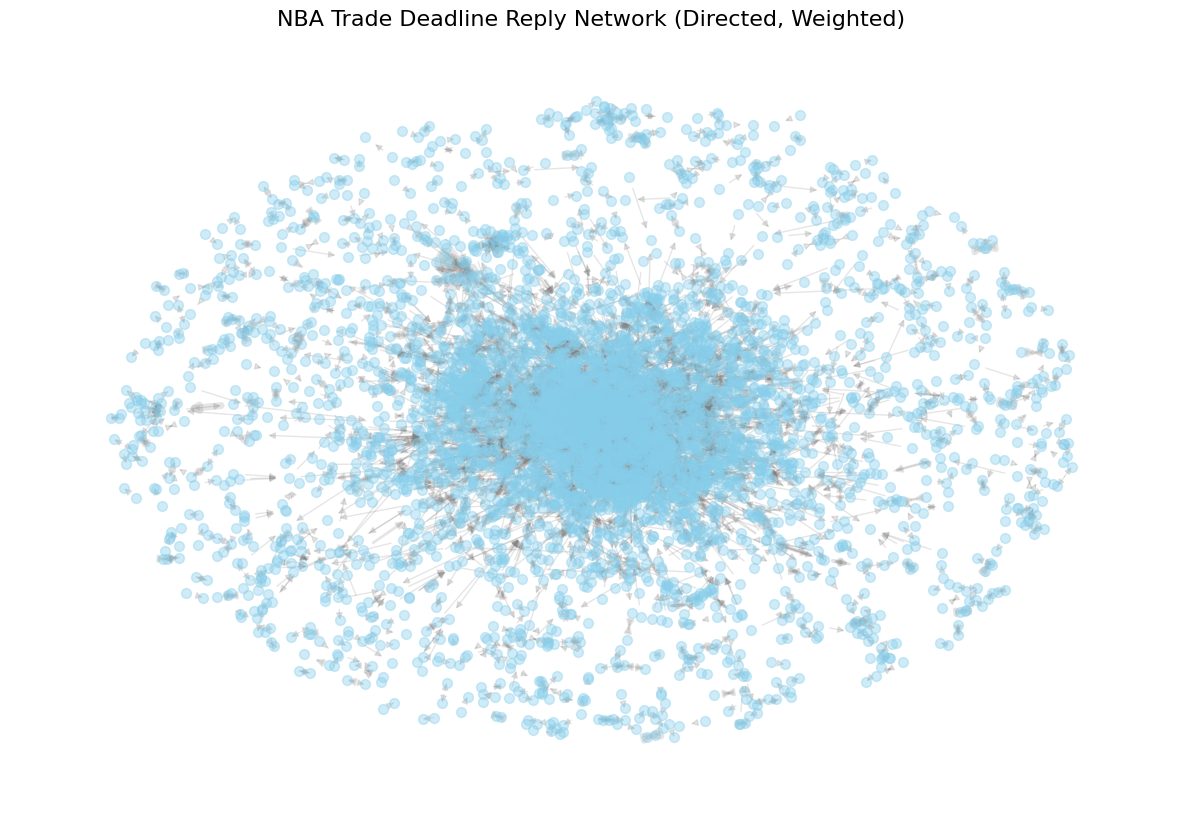

In [12]:
#Build reply graph
import networkx as nx
import matplotlib.pyplot as plt

#Build directed graph
G = nx.DiGraph()

#Iterate over response df and add edges and edge weights
for idx, row in weighted_edges.iterrows():
    G.add_edge(
        row['Source_Handle'],
        row['Target_Handle'],
        weight=row['Weight']
    )

#Node size is fixed
node_sizes = 50

# Edge widths proportional to weight
edge_widths = [G[u][v]['weight'] for u, v in G.edges()]

plt.figure(figsize=(15, 10))
# force-directed layout
pos = nx.spring_layout(G, k=0.5, seed=42)

#Draw network
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.4)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.2, edge_color='gray', arrows=True)

plt.title("NBA Trade Deadline Reply Network (Directed, Weighted)", fontsize=16)
plt.axis('off')
plt.show()

In [13]:
print('The network has:', len(G.nodes()), 'nodes')
print('The network has:', len(G.edges()), 'edges')

The network has: 5044 nodes
The network has: 6936 edges


In [14]:
print("The number of users posting who don't have an edge/don't reply and aren't replied to:",\
      nodes.User_DID.nunique() - len(G.nodes))
no_edges = nodes.User_DID.nunique() - len(G.nodes)
num_users = nodes.User_DID.nunique()
print(str(round(no_edges/num_users*100, 3)) + '% ' + 'of users')

The number of users posting who don't have an edge/don't reply and aren't replied to: 3060
37.759% of users


Text(0.5, 1.0, 'Boxplot of Edge Weight')

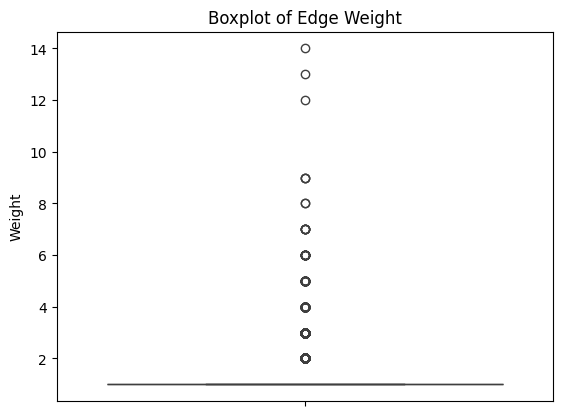

In [15]:
import seaborn as sns
sns.boxplot(weighted_edges.Weight)
plt.title('Boxplot of Edge Weight')

In [16]:
#Distribution of Edge Weight
weighted_edges.Weight.describe()

,Weight
count,6936.000000
mean,1.242359
std,0.729993
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,14.000000


In [17]:
page_cent = nx.pagerank(G, alpha = 0.85)
top_nodes = sorted(page_cent.items(), key=lambda x: x[1], reverse=True)[:15]
top_nodes = [(author, round(score, 4)) for author, score in top_nodes]
print('Highest pagerank authors:')
top_nodes

Highest pagerank authors:


[('shamsbot.bsky.social', 0.0135),
 ('chrislhayes.bsky.social', 0.0127),
 ('btoporek.bsky.social', 0.009),
 ('keithsmithnba.bsky.social', 0.008),
 ('theathletic.com', 0.0074),
 ('parkermolloy.com', 0.0065),
 ('davidbix.bsky.social', 0.0056),
 ('richardallensmith.com', 0.0055),
 ('hacks21.bsky.social', 0.0055),
 ('1robgunther.bsky.social', 0.0051),
 ('nbastat.bsky.social', 0.0048),
 ('misterjayem.bsky.social', 0.0047),
 ('jmcdonaldsa.bsky.social', 0.0045),
 ('jasonkirk.fyi', 0.0042),
 ('bwolfe6801.bsky.social', 0.004)]

Text(0.5, 1.0, 'Distribution of PageRank Scores')

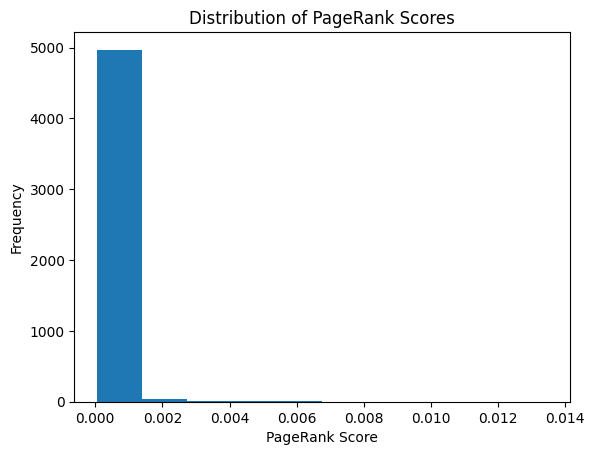

In [18]:
#Turn off wrapping
data_table.disable_dataframe_formatter()

page_ranks = pd.DataFrame(page_cent.values())

plt.hist(page_ranks)
plt.xlabel('PageRank Score')
plt.ylabel('Frequency')
plt.title('Distribution of PageRank Scores')

In [19]:
# Helper function for Freeman Centralization
def get_centralization(centrality_dict, n_nodes, metric_type="degree"):
    max_val = max(centrality_dict.values())
    sum_diff = sum(max_val - c for c in centrality_dict.values())

    #Denominator is maximum Value for each centrality metric
    #Since all metrics are normalized, denom is number of nodes - 1
    denom = n_nodes - 1

    # Return the Freeman Centralization
    return sum_diff / denom

In [20]:
#Calculate Freeman Centralization for the network
#It's how network centrality metrics compare to maximum theoretical centrality for each metric

#Number of nodes in the core
N = G.number_of_nodes()

#Get Centrality metrics for the core
in_degree = nx.in_degree_centrality(G)
out_degree = nx.out_degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G)

print(f"---NETWORK METRICS (N={N}) ---")
print(f"In-Degree Centralization:    {get_centralization(in_degree, N):.4f}")
print(f"Out-Degree Centralization:   {get_centralization(out_degree, N):.4f}")
print(f"Betweenness Centralization:  {get_centralization(betweenness, N, 'betweenness'):.4f}")
print(f"Closeness Centralization:    {get_centralization(closeness, N, 'closeness'):.4f}")
print(f"Eigenvector Centralization:  {get_centralization(eigenvector, N):.4f}")


---NETWORK METRICS (N=5044) ---
In-Degree Centralization:    0.0596
Out-Degree Centralization:   0.0065
Betweenness Centralization:  0.0193
Closeness Centralization:    0.0980
Eigenvector Centralization:  0.4300


Reply Network Core: Need a Degree of 5 to be included:

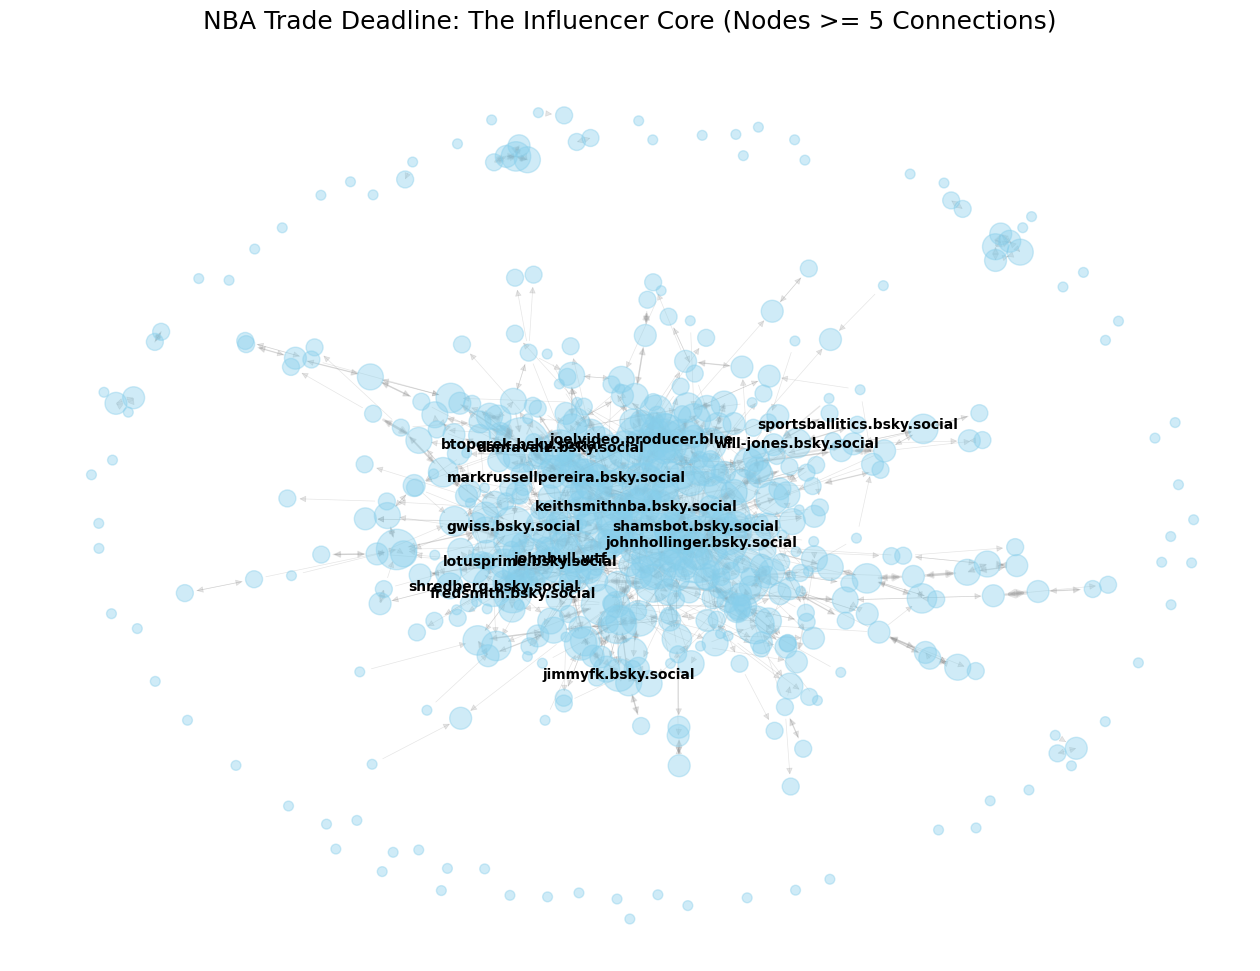

In [21]:
#Create new Directed Graph for the core
G_core = nx.DiGraph()

for idx, row in weighted_edges.iterrows():
    G_core.add_edge(
        row['Source_Handle'],
        row['Target_Handle'],
        weight=row['Weight']
    )

#Filter for the "Core" ---
# Keep only nodes with more than 5 connections (adjust this threshold as needed)
core_nodes = [node for node, degree in G.degree() if degree >= 5]
G_core = G.subgraph(core_nodes).copy()

#Identify Top Influencers for Labels - top 15 influencers with the higest pagerank
page_cent = nx.pagerank(G_core, alpha = 0.85)
top_nodes = sorted(page_cent.items(), key=lambda x: x[1], reverse=True)[:15]
labels = {node: node for node, val in top_nodes}

plt.figure(figsize=(16, 12))
# Higher k value spreads the core nodes out more
pos = nx.spring_layout(G_core, k=0.8, seed=42)

# Scale node size by In-Degree (popularity)
node_sizes = [G_core.in_degree(n) * 100 + 50 for n in G_core.nodes()]
edge_widths = [G_core[u][v]['weight'] * 0.5 for u, v in G_core.edges()]

#Draw network and labels
nx.draw_networkx_nodes(G_core, pos, node_size=node_sizes, node_color='skyblue', alpha=0.4)
nx.draw_networkx_edges(G_core, pos, width=edge_widths, alpha=0.2, edge_color='gray', arrows=True)
nx.draw_networkx_labels(G_core, pos, labels=labels, font_size=10, font_weight='bold')

plt.title("NBA Trade Deadline: The Influencer Core (Nodes >= 5 Connections)", fontsize=18)
plt.axis('off')
plt.show()

In [22]:
print('The core has:', len(G_core.nodes()), 'nodes')
print('The core has:', len(G_core.edges()), 'edges')

The core has: 565 nodes
The core has: 1290 edges


In [23]:
page_cent = nx.pagerank(G_core, alpha = 0.85)
top_nodes = sorted(page_cent.items(), key=lambda x: x[1], reverse=True)[:15]
top_nodes = [(author, round(score, 4)) for author, score in top_nodes]
print('Highest pagerank authors in the core:')
top_nodes

Highest pagerank authors in the core:


[('shamsbot.bsky.social', 0.0219),
 ('btoporek.bsky.social', 0.0217),
 ('keithsmithnba.bsky.social', 0.0153),
 ('johnbull.wtf', 0.0115),
 ('lotusprime.bsky.social', 0.0089),
 ('johnhollinger.bsky.social', 0.008),
 ('joelvideo.producer.blue', 0.0077),
 ('markrussellpereira.bsky.social', 0.0071),
 ('jimmyfk.bsky.social', 0.0069),
 ('fredsmith.bsky.social', 0.0068),
 ('will-jones.bsky.social', 0.0067),
 ('danfavale.bsky.social', 0.0065),
 ('shredberg.bsky.social', 0.0062),
 ('sportsballitics.bsky.social', 0.0062),
 ('gwiss.bsky.social', 0.0061)]

In [24]:
#Calculate Freeman Centralization for the core

#Number of nodes in the core
N_core = G_core.number_of_nodes()

#Get Centrality metrics for the core
core_in_degree = nx.in_degree_centrality(G_core)
core_out_degree = nx.out_degree_centrality(G_core)
core_betweenness = nx.betweenness_centrality(G_core)
core_closeness = nx.closeness_centrality(G_core)
core_eigenvector = nx.eigenvector_centrality(G_core)

print(f"--- CORE NETWORK METRICS (N={N_core}) ---")
print(f"In-Degree Centralization:    {get_centralization(core_in_degree, N_core):.4f}")
print(f"Out-Degree Centralization:   {get_centralization(core_out_degree, N_core):.4f}")
print(f"Betweenness Centralization:  {get_centralization(core_betweenness, N_core, 'betweenness'):.4f}")
print(f"Closeness Centralization:    {get_centralization(core_closeness, N_core, 'closeness'):.4f}")
print(f"Eigenvector Centralization:  {get_centralization(core_eigenvector, N):.4f}")

--- CORE NETWORK METRICS (N=565) ---
In-Degree Centralization:    0.1096
Out-Degree Centralization:   0.0279
Betweenness Centralization:  0.0981
Closeness Centralization:    0.1472
Eigenvector Centralization:  0.0462


In [25]:
print('The number of nodes with an edge', len(G.nodes))

The number of nodes with an edge 5044


In [26]:
print('Node density of entire network', str(round(nx.density(G)*100, 3)) + '%')

Node density of entire network 0.027%


Very sparse network.

In [27]:
print('Node density of core', str(round(nx.density(G_core)*100, 3)) + '%')

Node density of core 0.405%


The core is much more dense.

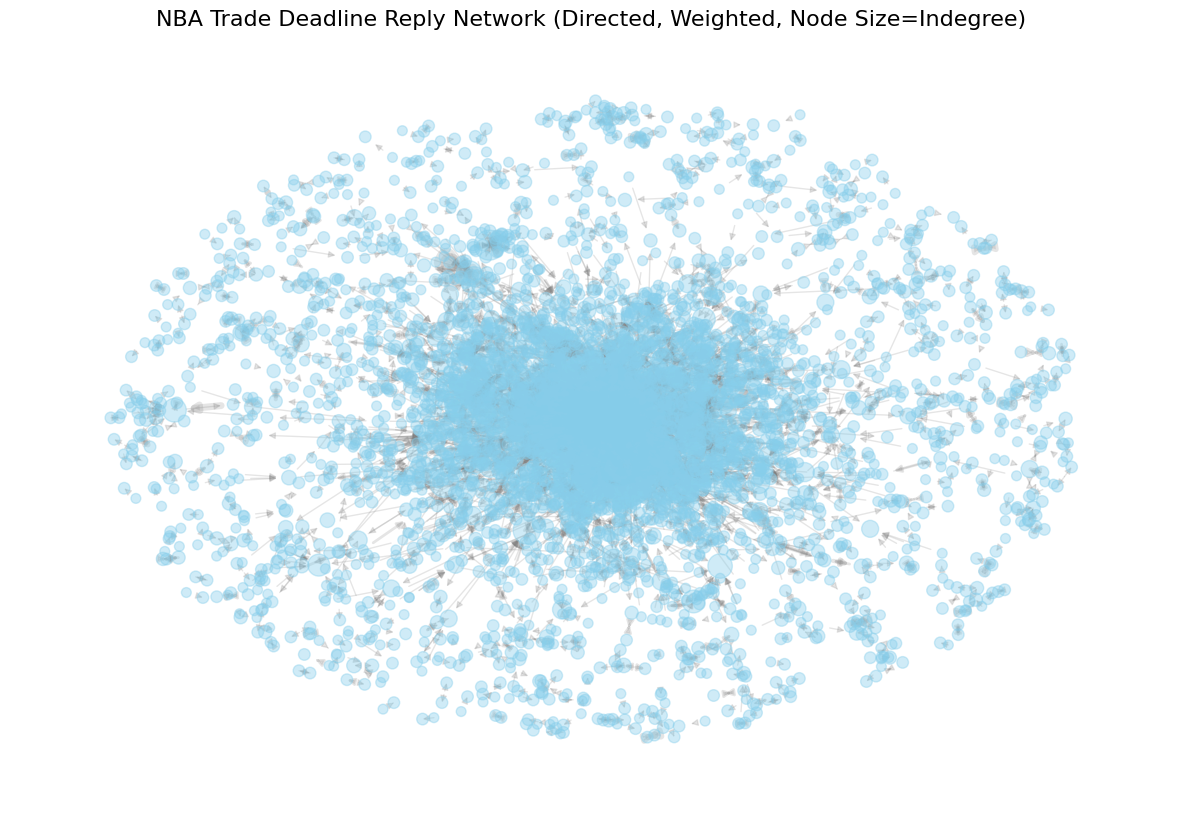

In [28]:
#Retweet network where indegree = size

G = nx.DiGraph()  # directed graph

for idx, row in weighted_edges.iterrows():
    G.add_edge(
        row['Source_Handle'],
        row['Target_Handle'],
        weight=row['Weight']
    )

#Node sizes proportional to indegree
node_sizes = [50 + 20 * G.in_degree(n) for n in G.nodes()]

# Edge widths proportional to weight
edge_widths = [G[u][v]['weight'] for u, v in G.edges()]


plt.figure(figsize=(15, 10))
pos = nx.spring_layout(G, k=0.5, seed=42)

# Draw nodes & edges (directed, weighted, no labels)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.4)
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.2, edge_color='gray', arrows=True)

plt.title("NBA Trade Deadline Reply Network (Directed, Weighted, Node Size=Indegree)", fontsize=16)
plt.axis('off')
plt.show()

In [29]:
#Find nodes that are replied to and replying the most

#Indegree and outdegree for each author/node
indegree_dict = dict(G.in_degree())
outdegree_dict = dict(G.out_degree())

#Find top nodes
top_indegree = sorted(indegree_dict.items(), key=lambda x: x[1], reverse=True)[:20]
top_outdegree = sorted(outdegree_dict.items(), key=lambda x: x[1], reverse=True)[:20]

#Top 10 nodes with the higest indegree (most replies) and out degree (replies the most)
print("Top 10 nodes by indegree (most replied-to):")
for node, degree in top_indegree:
    print(f"{node}: {degree}")

print("\nTop 10 nodes by outdegree (most active):")
for node, degree in top_outdegree:
    print(f"{node}: {degree}")

Top 10 nodes by indegree (most replied-to):
shamsbot.bsky.social: 302
theathletic.com: 176
chrislhayes.bsky.social: 129
keithsmithnba.bsky.social: 109
nba.com: 99
markjacob.bsky.social: 74
parkermolloy.com: 66
washingtonstatestandard.com: 63
btoporek.bsky.social: 60
jimowczarski.bsky.social: 57
jmcdonaldsa.bsky.social: 49
mikeascotto.bsky.social: 42
nbastat.bsky.social: 36
1robgunther.bsky.social: 33
johnhollinger.bsky.social: 32
brenda2026.bsky.social: 31
davidbix.bsky.social: 31
michaelvpina.bsky.social: 30
mrbuckbucknba.bsky.social: 29
lawmurraythenu.bsky.social: 27

Top 10 nodes by outdegree (most active):
btoporek.bsky.social: 34
johnbull.wtf: 24
brenda2026.bsky.social: 21
keithsmithnba.bsky.social: 20
tediosa-miss.bsky.social: 19
joelvideo.producer.blue: 19
lotusprime.bsky.social: 17
courtneyfox1.bsky.social: 17
alexfrompgh.bsky.social: 17
getsit.bsky.social: 17
noeldickover.bsky.social: 17
mentoch.bsky.social: 16
markrussellpereira.bsky.social: 15
jimowczarski.bsky.social: 14
su

In [30]:
#Are there any blue sky servers that are more common?
#How often do replies cross server?

#Split user handle on the dot
nodes['Server'] = nodes['User_Handle'].apply(lambda x: x.split('.')[-1] if '.' in x else 'unknown')

#Group unique users by server
server_counts = nodes.groupby('Server')['User_Handle'].nunique().sort_values(ascending=False)

#Calculate the total number of unique users across all servers
total_unique_users = server_counts.sum()

# Create a DataFrame for a clean "Server Report"
server_report = pd.DataFrame({
    'Unique_Users': server_counts,
    'Percent_of_Total': (server_counts / total_unique_users) * 100
})

print("Number of unique users per server:")
print(server_report.head(10).round(2))


# Check edges crossing servers
# Merge edge info with server info
edges_with_server = raw_interactions.merge(
    nodes[['User_Handle', 'Server']], left_on='Source_Handle', right_on='User_Handle', how='left'
).rename(columns={'Server':'Source_Server'}).drop(columns=['User_Handle'])

edges_with_server = edges_with_server.merge(
    nodes[['User_Handle', 'Server']], left_on='Target_Handle', right_on='User_Handle', how='left'
).rename(columns={'Server':'Target_Server'}).drop(columns=['User_Handle'])

#Cross_Server is true if source server = target server, is false if they're different
edges_with_server['Cross_Server'] = edges_with_server['Source_Server'] != edges_with_server['Target_Server']

#Number of edges
total_edges = len(edges_with_server)
#Number of edges crossing servers
cross_edges = edges_with_server['Cross_Server'].sum()
print(f"\nTotal edges: {total_edges}")
print(f"Edges crossing servers: {cross_edges} ({cross_edges/total_edges*100:.2f}%)")

Number of unique users per server:
        Unique_Users  Percent_of_Total
Server                                
social          7412             91.47
com              317              3.91
app               72              0.89
gy                45              0.56
net               26              0.32
org               20              0.25
online            18              0.22
news              12              0.15
ca                11              0.14
xyz               10              0.12

Total edges: 2262042
Edges crossing servers: 396641 (17.53%)


In [31]:
!pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 48.4 MB/s eta 0:00:00


In [32]:
import igraph as ig

# Prepare the list of tuples (source, target, weight)
edges_for_igraph = weighted_edges[['Source_Handle', 'Target_Handle', 'Weight']].values.tolist()

g = ig.Graph.TupleList(edges_for_igraph,
                       directed=True,
                       weights=True)

#Apply the community_leiden algorithm ---
# Set objective_function to "modularity" and directed to True (which is the default for a directed graph in Leiden)
communities = g.community_leiden(objective_function="modularity", weights='weight', n_iterations = 100)

#Extract the modularity score ---
modularity = communities.modularity

print(f"Directed Modularity (Leiden): {modularity:.4f}")

Directed Modularity (Leiden): 0.8783


Users responses are very fragmented. People likely aren't replying very much beyond they're initial response thread.

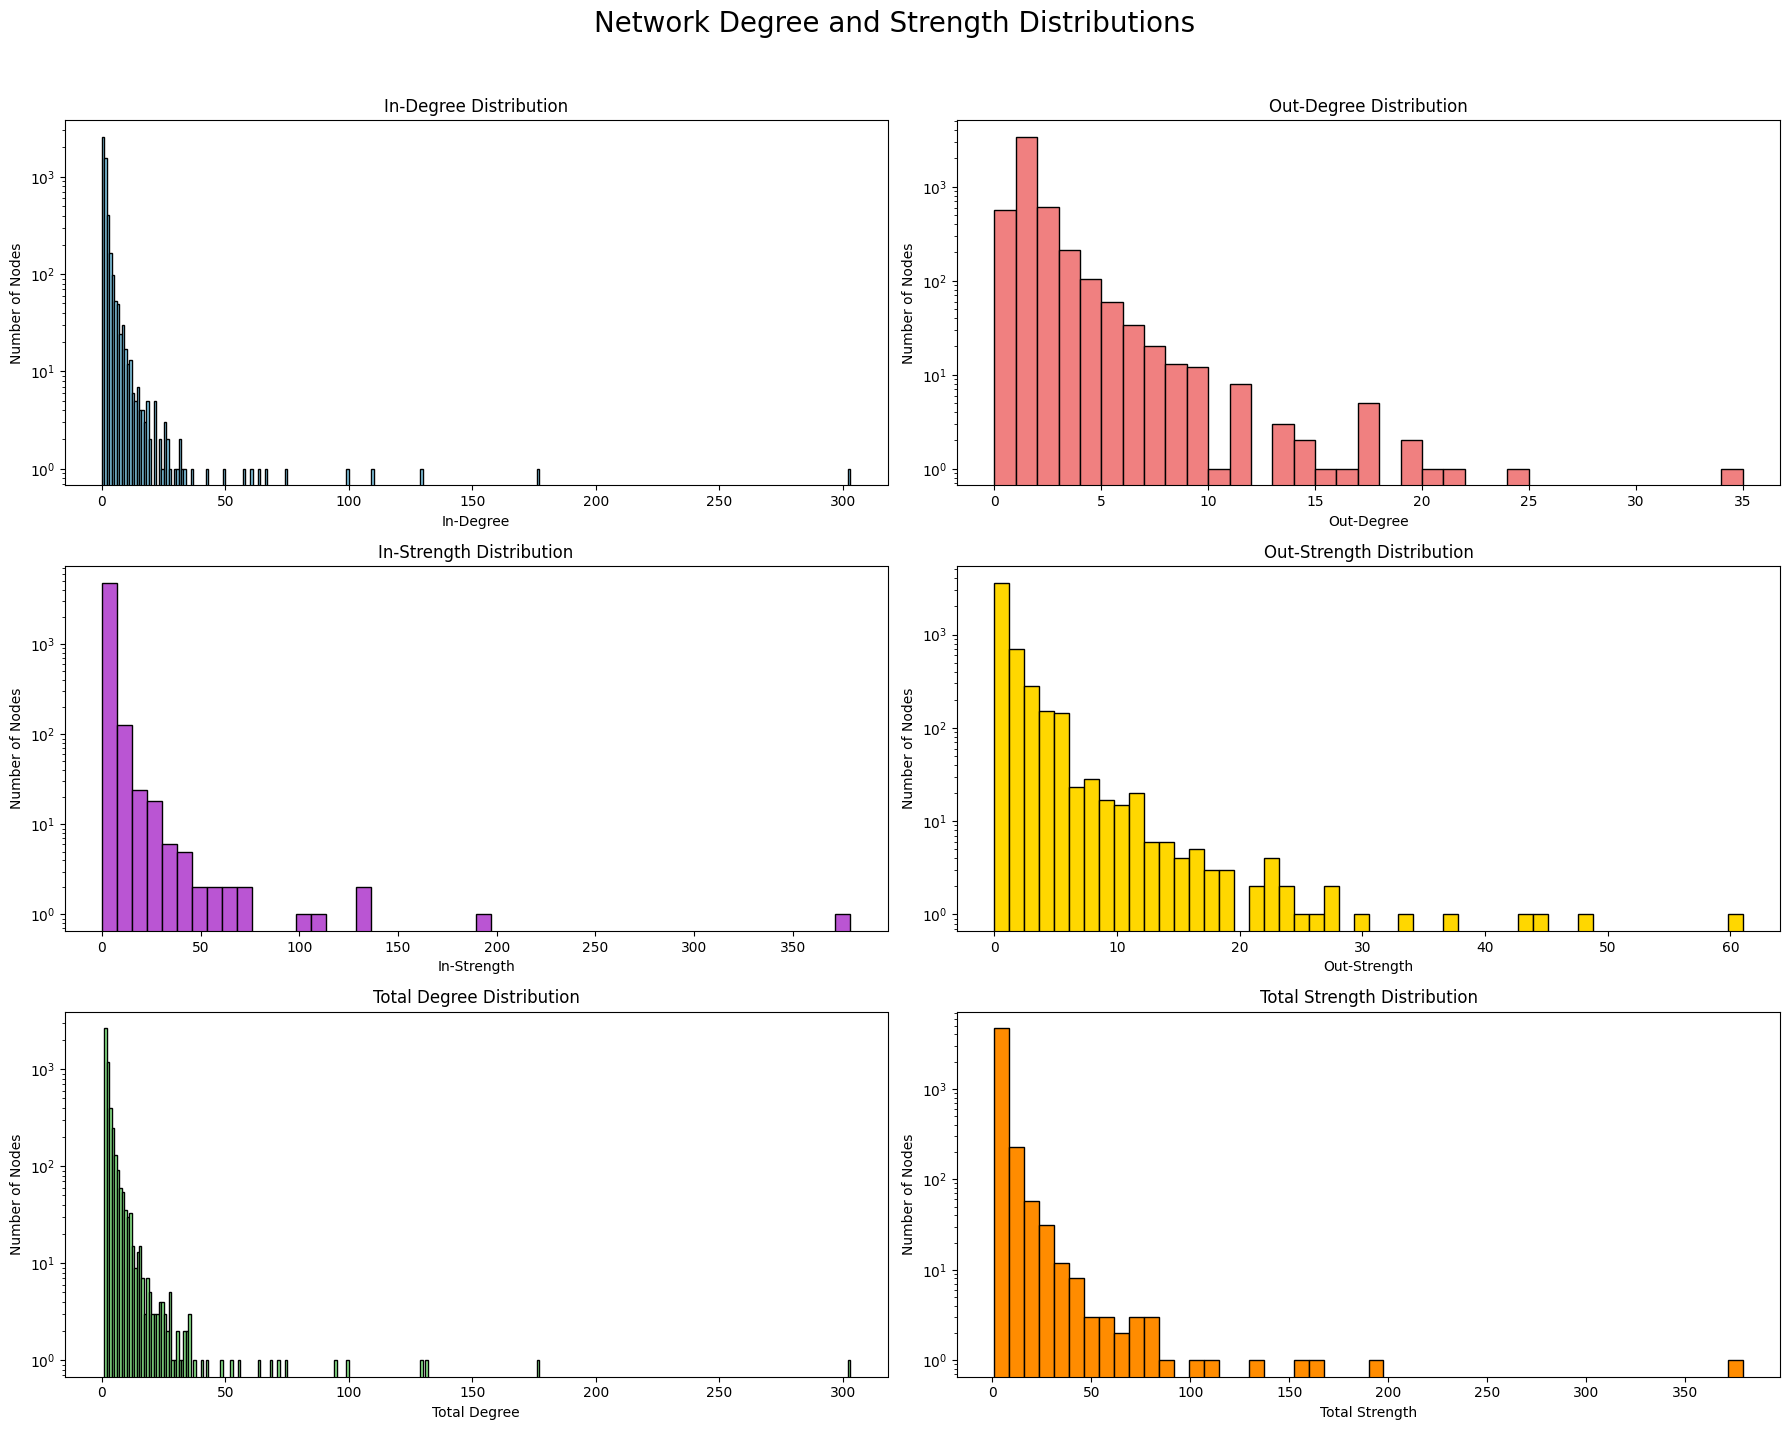

In [33]:
#Histograms of in degree, out degree, total degree, in-strength, out-strength, and total strength  distribution

#Calculate degree distributions ---
# In-degree: number of incoming edges
in_degrees = [G.in_degree(node) for node in G.nodes()]
# Out-degree: number of outgoing edges
out_degrees = [G.out_degree(node) for node in G.nodes()]
# Total degree: sum of in-degree and out-degree
total_degrees = [G.degree(node) for node in G.nodes()]

# Calculate strength distributions (considering edge weights) ---
# In-strength: sum of weights of incoming edges
in_strengths = [G.in_degree(node, weight='weight') for node in G.nodes()]
# Out-strength: sum of weights of outgoing edges
out_strengths = [G.out_degree(node, weight='weight') for node in G.nodes()]
# Total strength: sum of weights of all incoming and outgoing edges
total_strengths = [G.degree(node, weight='weight') for node in G.nodes()]

# --- 3. Create histograms for each distribution ---
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle('Network Degree and Strength Distributions', fontsize=20)

# In-degree histogram
axes[0, 0].hist(in_degrees, bins=range(max(in_degrees) + 2), color='skyblue', edgecolor='black')
axes[0, 0].set_title('In-Degree Distribution')
axes[0, 0].set_xlabel('In-Degree')
axes[0, 0].set_ylabel('Number of Nodes')
# Log scale for better visibility of skewed distributions
axes[0, 0].set_yscale('log')

# Out-degree histogram
axes[0, 1].hist(out_degrees, bins=range(max(out_degrees) + 2), color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Out-Degree Distribution')
axes[0, 1].set_xlabel('Out-Degree')
axes[0, 1].set_ylabel('Number of Nodes')
axes[0, 1].set_yscale('log')

# Total degree histogram
axes[2, 0].hist(total_degrees, bins=range(max(total_degrees) + 2), color='lightgreen', edgecolor='black')
axes[2, 0].set_title('Total Degree Distribution')
axes[2, 0].set_xlabel('Total Degree')
axes[2, 0].set_ylabel('Number of Nodes')
axes[2, 0].set_yscale('log')

# In-strength histogram
axes[1, 0].hist(in_strengths, bins=50, color='mediumorchid', edgecolor='black')
axes[1, 0].set_title('In-Strength Distribution')
axes[1, 0].set_xlabel('In-Strength')
axes[1, 0].set_ylabel('Number of Nodes')
axes[1, 0].set_yscale('log')

# Out-strength histogram
axes[1, 1].hist(out_strengths, bins=50, color='gold', edgecolor='black')
axes[1, 1].set_title('Out-Strength Distribution')
axes[1, 1].set_xlabel('Out-Strength')
axes[1, 1].set_ylabel('Number of Nodes')
axes[1, 1].set_yscale('log')

# Total strength histogram
axes[2, 1].hist(total_strengths, bins=50, color='darkorange', edgecolor='black')
axes[2, 1].set_title('Total Strength Distribution')
axes[2, 1].set_xlabel('Total Strength')
axes[2, 1].set_ylabel('Number of Nodes')
axes[2, 1].set_yscale('log')

# Adjust layout to prevent title overlap
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In Strength Distribution

In [34]:
#Distribution of in strength for each author
weight_sums = weighted_edges.groupby('Target_DID')['Weight'].sum()
weight_sums.describe()

,Weight
count,2478.000000
mean,3.477401
std,11.030699
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,379.000000


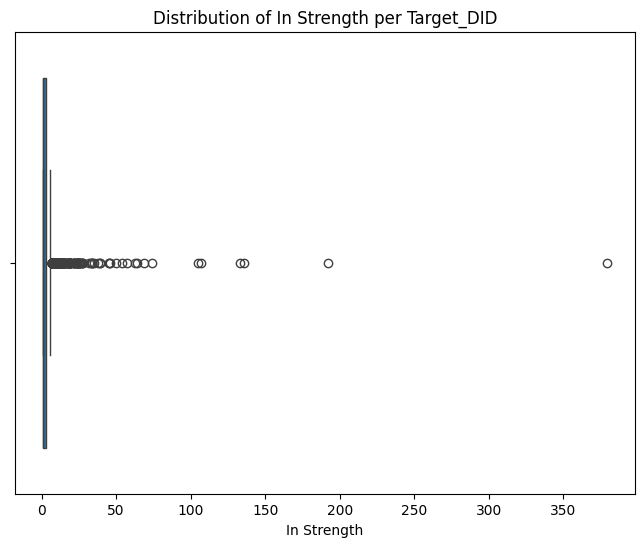

In [35]:
#boxplot of in strength for authors
plt.figure(figsize=(8, 6))
sns.boxplot(x=weight_sums)

plt.title('Distribution of In Strength per Target_DID')
plt.xlabel('In Strength')
plt.show()

Out Strength Distribution

In [36]:
#Distribution of out strength for each author
weight_sums = weighted_edges.groupby('Source_DID')['Weight'].sum()
weight_sums.describe()

,Weight
count,4483.000000
mean,1.922150
std,2.740438
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,61.000000


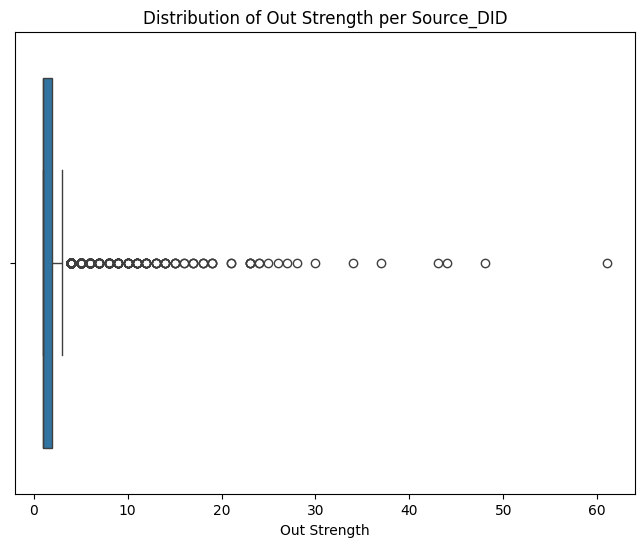

In [37]:
#boxplot of out strength for authors
plt.figure(figsize=(8, 6))
sns.boxplot(x=weight_sums)

plt.title('Distribution of Out Strength per Source_DID')
plt.xlabel('Out Strength')
plt.show()

In [38]:
in_degree = nx.in_degree_centrality(G)
out_degree = nx.out_degree_centrality(G)
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
eigenvector = nx.eigenvector_centrality(G)
pagerank_scores = nx.pagerank(G, alpha=0.85)

In [39]:
import numpy as np

#Find top 5 nodes for a normalized metric and normalized metric average
def get_top_nodes(centrality_dict):
  #Calculate metric mean
  metric_mean = float(round(np.mean([node[1] for node in centrality_dict.items()]), 4))
  #Find top 5 nodes for the metric
  top_nodes = sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:5]
  top_nodes = [(author, round(score, 4)) for author, score in top_nodes]
  print('Top 5 Highest nodes:')
  for node in top_nodes:
    print(node[0] + ':', node[1])
  print('Normalized Network Mean:', metric_mean)

In [40]:
print('Normalized In-Degree:')
get_top_nodes(in_degree)
print()

print('Normalized Out-Degree:')
get_top_nodes(out_degree)
print()

print('Normalized Betweeness:')
get_top_nodes(betweenness)
print()

print('Normalized Closeness:')
get_top_nodes(closeness)
print()

print('Normalized Eigenvector:')
get_top_nodes(eigenvector)
print()

print('Normalized Pagerank:')
get_top_nodes(pagerank_scores)

Normalized In-Degree:
Top 5 Highest nodes:
shamsbot.bsky.social: 0.0599
theathletic.com: 0.0349
chrislhayes.bsky.social: 0.0256
keithsmithnba.bsky.social: 0.0216
nba.com: 0.0196
Normalized Network Mean: 0.0003

Normalized Out-Degree:
Top 5 Highest nodes:
btoporek.bsky.social: 0.0067
johnbull.wtf: 0.0048
brenda2026.bsky.social: 0.0042
keithsmithnba.bsky.social: 0.004
tediosa-miss.bsky.social: 0.0038
Normalized Network Mean: 0.0003

Normalized Betweeness:
Top 5 Highest nodes:
keithsmithnba.bsky.social: 0.0194
btoporek.bsky.social: 0.0176
johnbull.wtf: 0.0133
mrbuckbucknba.bsky.social: 0.0091
markrussellpereira.bsky.social: 0.0085
Normalized Network Mean: 0.0001

Normalized Closeness:
Top 5 Highest nodes:
shamsbot.bsky.social: 0.1066
keithsmithnba.bsky.social: 0.0828
theathletic.com: 0.0809
johnhollinger.bsky.social: 0.0723
sjkamin.bsky.social: 0.0683
Normalized Network Mean: 0.0087

Normalized Eigenvector:
Top 5 Highest nodes:
keithsmithnba.bsky.social: 0.4323
btoporek.bsky.social: 0.344

In [41]:
#Calculates node reciprocity (what percent of edges go both ways)
reciprocity = nx.reciprocity(G)
print("Reciprocity:", round(reciprocity, 4))

Reciprocity: 0.3587


In [42]:
#Calculates degree assortativity (the tendency of nodes to talk to other nodes of similar degree)
assortativity = nx.degree_assortativity_coefficient(G)
print("Assortativity:", round(assortativity, 4))

Assortativity: -0.0964


In [43]:
# Compute the average clustering coefficient for the entire graph
average_coefficient = nx.average_clustering(G)

print("Clustering coefficients per node:", round(average_coefficient, 4))

Clustering coefficients per node: 0.0313


In [44]:
#Find number of weakly connected components
num_weak = nx.number_weakly_connected_components(G)
print(f'Number of weakly connected components: {num_weak}')

weak_components = nx.weakly_connected_components(G)

# Find the largest weakly connected component
largest_cc = max(weak_components, key=len)
print(f"Size of largest weakly connected component: {len(largest_cc)} nodes")

Number of weakly connected components: 492
Size of largest weakly connected component: 3688 nodes


In [45]:
#Find the average size of weakly connected componentss
weak_components = list(nx.weakly_connected_components(G))
num_components = len(weak_components)
total_nodes = G.number_of_nodes()

avg_size = total_nodes / num_components
print(f"Average component size: {avg_size:.2f} nodes")

Average component size: 10.25 nodes


**Research Question 2: How does the structural organization of the reply network evolve in response to major trade events?**

In [46]:
#Round each post time down to the nearest 10 minutes
nodes["time_bin"] = nodes["Date_ET"].dt.floor("10min")

#Find how many posts are posted every 10 minutes
posts_per_10min = nodes.groupby("time_bin")["Post_ID"].count()

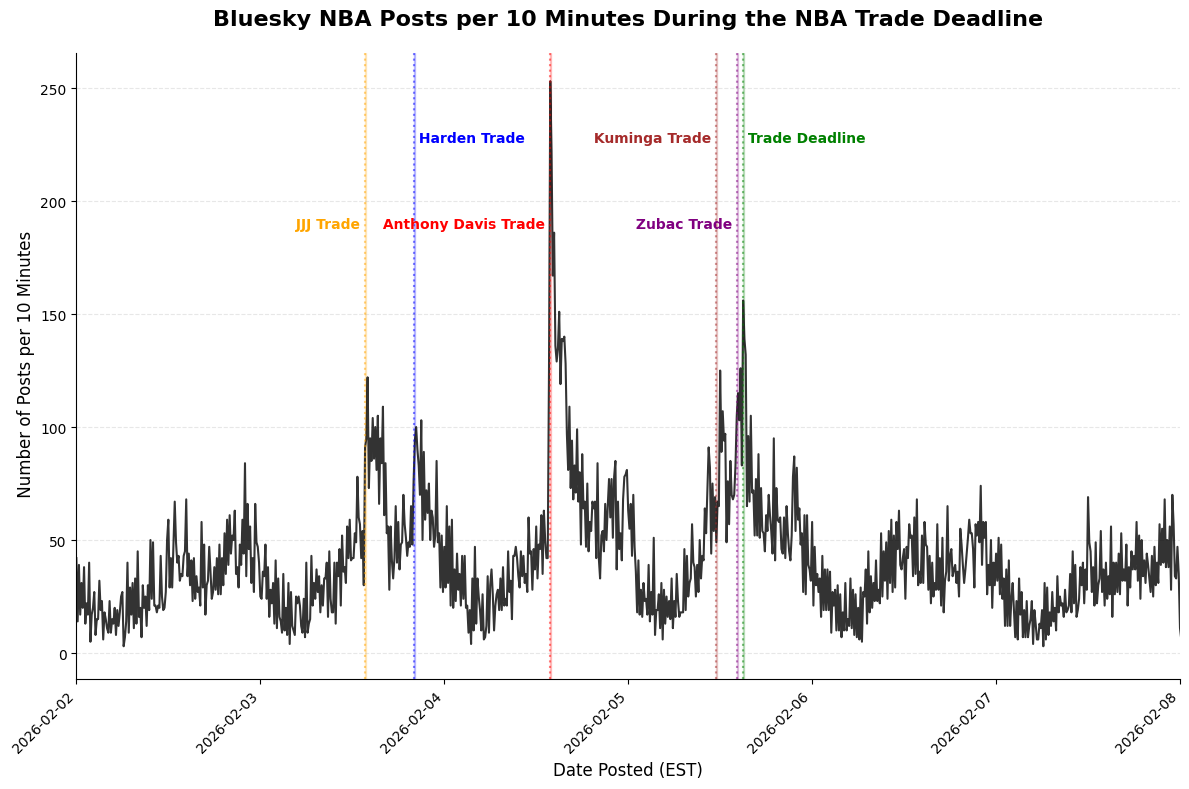

In [47]:
#Visualization of Posts per 10 minutes

# Ensure index is naive to prevent plotting errors
posts_per_10min.index = posts_per_10min.index.tz_localize(None)

plt.figure(figsize=(12, 8))
ax = posts_per_10min.plot(color='black', linewidth=1.5, alpha=0.8)

# Event dictionary
# name: Display name
# time: Start timestamp (Using Shams Tweet Twitter Trade Timestamp for Trades)
# color: Color for span and text
# y_pct: Height of the label (0 to 1)
# ha: Horizontal alignment ('right' for early peaks, 'left' for later)
events = [
    {"name": "JJJ Trade", "time": "2026-02-03 13:41", "color": "orange", "y_pct": 0.75, "ha": "right"},
    {"name": "Harden Trade", "time": "2026-02-03 20:03", "color": "blue", "y_pct": 0.90, "ha": "left"},
    {"name": "Anthony Davis Trade", "time": "2026-02-04 13:44", "color": "red", "y_pct": 0.75, "ha": "right"},
    {"name": "Kuminga Trade", "time": "2026-02-05 11:28", "color": "brown", "y_pct": 0.90, "ha": "right"},
    {"name": "Zubac Trade", "time": "2026-02-05 14:11", "color": "purple", "y_pct": 0.75, "ha": "right"},
    {"name": "Trade Deadline", "time": "2026-02-05 15:00", "color": "green", "y_pct": 0.90, "ha": "left"},
]

#Number of 10 minute intervals
max_posts = posts_per_10min.max()

#Show the events
for ev in events:
    start = pd.Timestamp(ev['time'])
    end = start + pd.Timedelta(minutes=10)

    # Draw vertical span at event
    ax.axvspan(start, end, color=ev['color'], alpha=0.2)

    # Add vertical line for precise timing
    ax.axvline(start, color=ev['color'], linestyle=':', alpha=0.5)

    # Add text label with a small offset for readability
    ax.text(start, max_posts * ev['y_pct'], f" {ev['name']} ",
            color=ev['color'], fontsize=10, fontweight='bold',
            ha=ev['ha'], va='center', clip_on=True)

plt.title("Bluesky NBA Posts per 10 Minutes During the NBA Trade Deadline", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Date Posted (EST)", fontsize=12)
plt.ylabel(" Number of Posts per 10 Minutes", fontsize=12)

# Set focused x-limits
plt.xlim(pd.Timestamp('2026-02-02'), pd.Timestamp('2026-02-08'))

# Clean up axes
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [48]:
#10 minute intervals with the most posts
posts_per_10min.sort_values(ascending = False)[:10]

,Post_ID
time_bin,
2026-02-04 13:50:00,253
2026-02-04 14:00:00,222
2026-02-04 14:20:00,186
2026-02-04 14:10:00,167
2026-02-05 15:00:00,156
2026-02-04 15:00:00,151
2026-02-04 15:40:00,140
2026-02-05 15:10:00,139
2026-02-04 15:20:00,139


In [49]:
#Distribution of number of posts per 10 minutes
posts_per_10min.describe()

,Post_ID
count,1013.000000
mean,35.971372
std,28.998504
min,1.000000
25%,16.000000
50%,32.000000
75%,49.000000
max,253.000000


In [50]:
#Round each post down to nearest hour interval
nodes["time_bin"] = nodes["Date_ET"].dt.floor("60min")

#Number of posts per hour
posts_per_60min = nodes.groupby("time_bin")["Post_ID"].count()

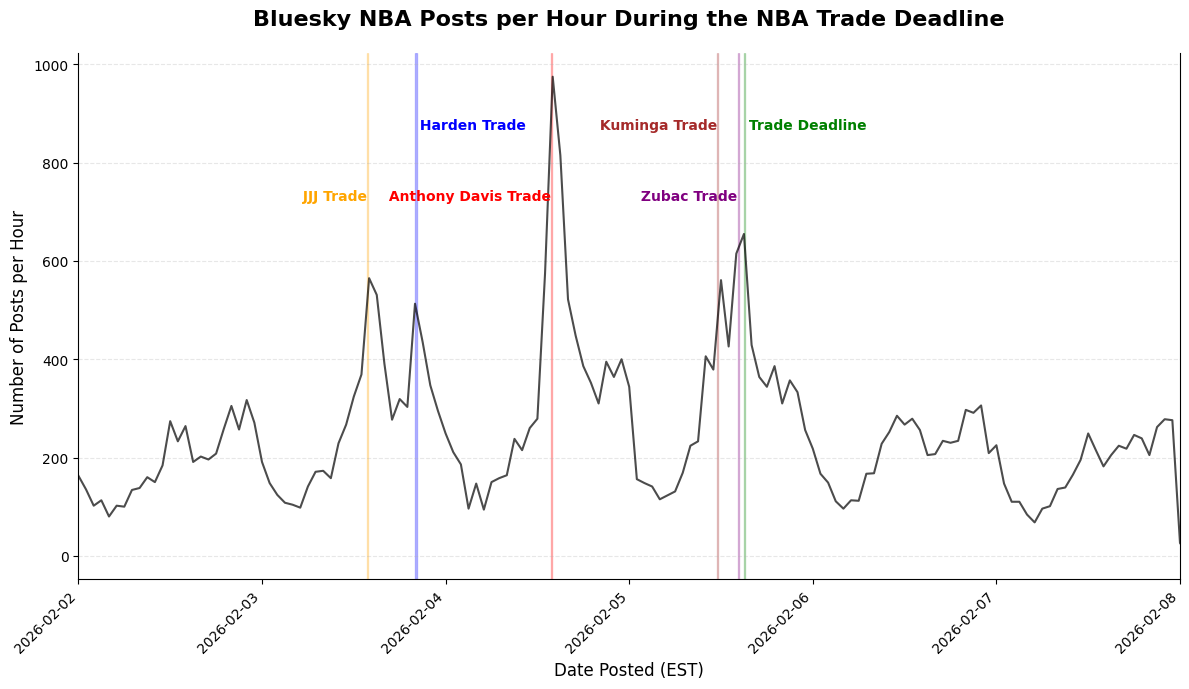

In [69]:
#Visualization of Posts per Hour

plt.figure(figsize=(12, 7))
ax = posts_per_60min.plot(color='black', alpha=0.7)
plt.xlabel("Date Posted (EST)", fontsize = 12)
plt.ylabel("Number of Posts per Hour", fontsize = 12)
plt.title("Bluesky NBA Posts per Hour During the NBA Trade Deadline", fontsize=16, fontweight='bold', pad = 20)

plt.xlim(pd.Timestamp('2026-02-02 00:00:00'), pd.Timestamp('2026-02-08 00:00:00'))
max_val = posts_per_60min.max()

#Define All Events
events = [
    {"name": "JJJ Trade", "time": "2026-02-03 13:41", "color": "orange", "y_mult": 0.75, "ha": "right"},
    {"name": "Harden Trade", "time": "2026-02-03 20:03", "color": "blue", "y_mult": 0.90, "ha": "left"},
    {"name": "Anthony Davis Trade", "time": "2026-02-04 13:44", "color": "red", "y_mult": 0.75, "ha": "right"},
    {"name": "Kuminga Trade", "time": "2026-02-05 11:28", "color": "brown", "y_mult": 0.90, "ha": "right"},
    {"name": "Zubac Trade", "time": "2026-02-05 14:11", "color": "purple", "y_mult": 0.75, "ha": "right"},
    {"name": "Trade Deadline", "time": "2026-02-05 15:00", "color": "green", "y_mult": 0.90, "ha": "left"},
]

#Show the events
for ev in events:
    start = pd.Timestamp(ev['time'])
    end = start + pd.Timedelta(minutes=10)

    # Add the vertical shaded area
    ax.axvspan(start, end, color=ev['color'], alpha=0.25)

    # Add the text label
    ax.text(start, max_val * ev['y_mult'], f" {ev['name']}",
            color=ev['color'], fontsize=10, fontweight='bold',
            ha=ev['ha'], va='center')

# 4. Final Formatting
ax.spines['top'].set_visible(False)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [52]:
#1 Hour intervals with the most posts
posts_per_60min.sort_values(ascending = False)[:10]

,Post_ID
time_bin,
2026-02-04 14:00:00+00:00,975
2026-02-04 15:00:00+00:00,815
2026-02-05 15:00:00+00:00,655
2026-02-05 14:00:00+00:00,615
2026-02-04 13:00:00+00:00,575
2026-02-03 14:00:00+00:00,565
2026-02-05 12:00:00+00:00,561
2026-02-03 15:00:00+00:00,531
2026-02-04 16:00:00+00:00,522


In [53]:
#Distribution of number of posts per hour
posts_per_60min.describe()

,Post_ID
count,229.000000
mean,159.122271
std,164.867844
min,1.000000
25%,2.000000
50%,141.000000
75%,256.000000
max,975.000000


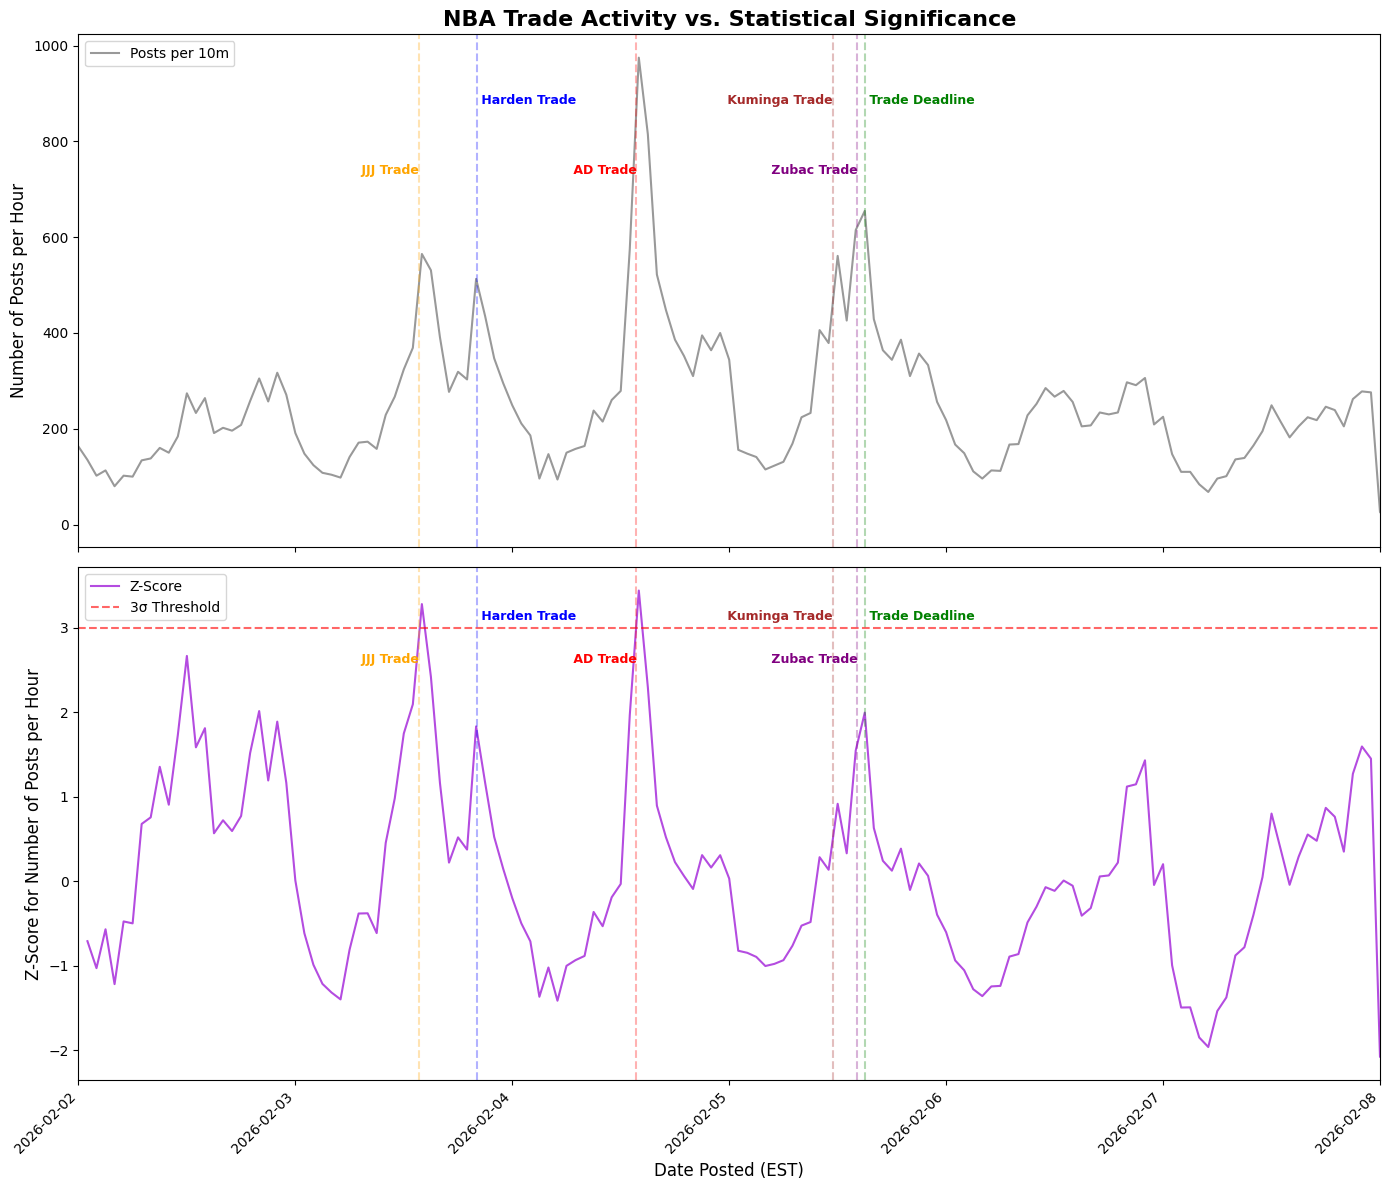

In [54]:
#Number of posts per hour vs Z-Score for the day

posts_per_60min.index = posts_per_60min.index.tz_localize(None)

#Rolling Z score for every 24 hours
window = 24
rolling_mean = posts_per_60min.rolling(window=window, min_periods=1).mean()
rolling_std = posts_per_60min.rolling(window=window, min_periods=1).std()
z_scores = (posts_per_60min - rolling_mean) / (rolling_std + 1e-6)

#Events
events = [
    {"name": "JJJ Trade", "time": "2026-02-03 13:41", "color": "orange", "y_pct": 0.75, "align": "right"},
    {"name": "Harden Trade", "time": "2026-02-03 20:03", "color": "blue", "y_pct": 0.90, "align": "left"},
    {"name": "AD Trade", "time": "2026-02-04 13:44", "color": "red", "y_pct": 0.75, "align": "right"},
    {"name": "Kuminga Trade", "time": "2026-02-05 11:28", "color": "brown", "y_pct": 0.90, "align": "right"},
    {"name": "Zubac Trade", "time": "2026-02-05 14:11", "color": "purple", "y_pct": 0.75, "align": "right"},
    {"name": "Trade Deadline", "time": "2026-02-05 15:00", "color": "green", "y_pct": 0.90, "align": "left"},
]


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Top Plot: Number of Posts per Hour
posts_per_60min.plot(ax=ax1, color='black', alpha=0.4, label="Posts per 10m")
ax1.set_title("NBA Trade Activity vs. Statistical Significance", fontsize=16, fontweight='bold')
ax1.set_ylabel("Number of Posts per Hour", fontsize = 12)

# Bottom Plot: Z-Score over 24 hour rolling period
z_scores.plot(ax=ax2, color='darkviolet', alpha=0.7, label="Z-Score")
ax2.axhline(y=3, color='red', linestyle='--', alpha=0.6, label="3σ Threshold")
ax2.set_ylabel("Z-Score for Number of Posts per Hour", fontsize = 12)
ax2.set_xlabel("Date Posted (EST)", fontsize = 12)

# 5. Add Events to BOTH plots
max_posts = posts_per_60min.max()
max_z = z_scores.max()

for ev in events:
    ts = pd.Timestamp(ev['time'])
    # Add vertical span to both
    for ax in [ax1, ax2]:
        ax.axvline(ts, color=ev['color'], alpha=0.3, linestyle='--')

    # Text for top plot (using y_pct of max posts)
    ax1.text(ts, max_posts * ev['y_pct'], f" {ev['name']}",
             color=ev['color'], fontweight='bold', ha=ev['align'], fontsize=9)

    # Text for bottom plot (using y_pct of max Z-score)
    ax2.text(ts, max_z * ev['y_pct'], f" {ev['name']}",
             color=ev['color'], fontweight='bold', ha=ev['align'], fontsize=9)

# Formatting
plt.xlim(pd.Timestamp('2026-02-02'), pd.Timestamp('2026-02-08'))
plt.xticks(rotation=45)
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

Overlay with reply ratio to see if spikes are broadcasts (people discuss the trade deadline) or conversations (people replying to each other).

In [55]:
#ID for an reply
reply_ids = set(raw_interactions['Post_ID'])

#Add a post type column, if a post is in the reply_ids it's a reply, else it's an original post
nodes['post_type'] = np.where(
    nodes['Post_ID'].isin(reply_ids),
    'reply',
    'original_post'
)

#See the reply distribution
print("Composition of the Network:")
print(nodes['post_type'].value_counts())

Composition of the Network:
post_type
original_post    27822
reply             8617
Name: count, dtype: int64


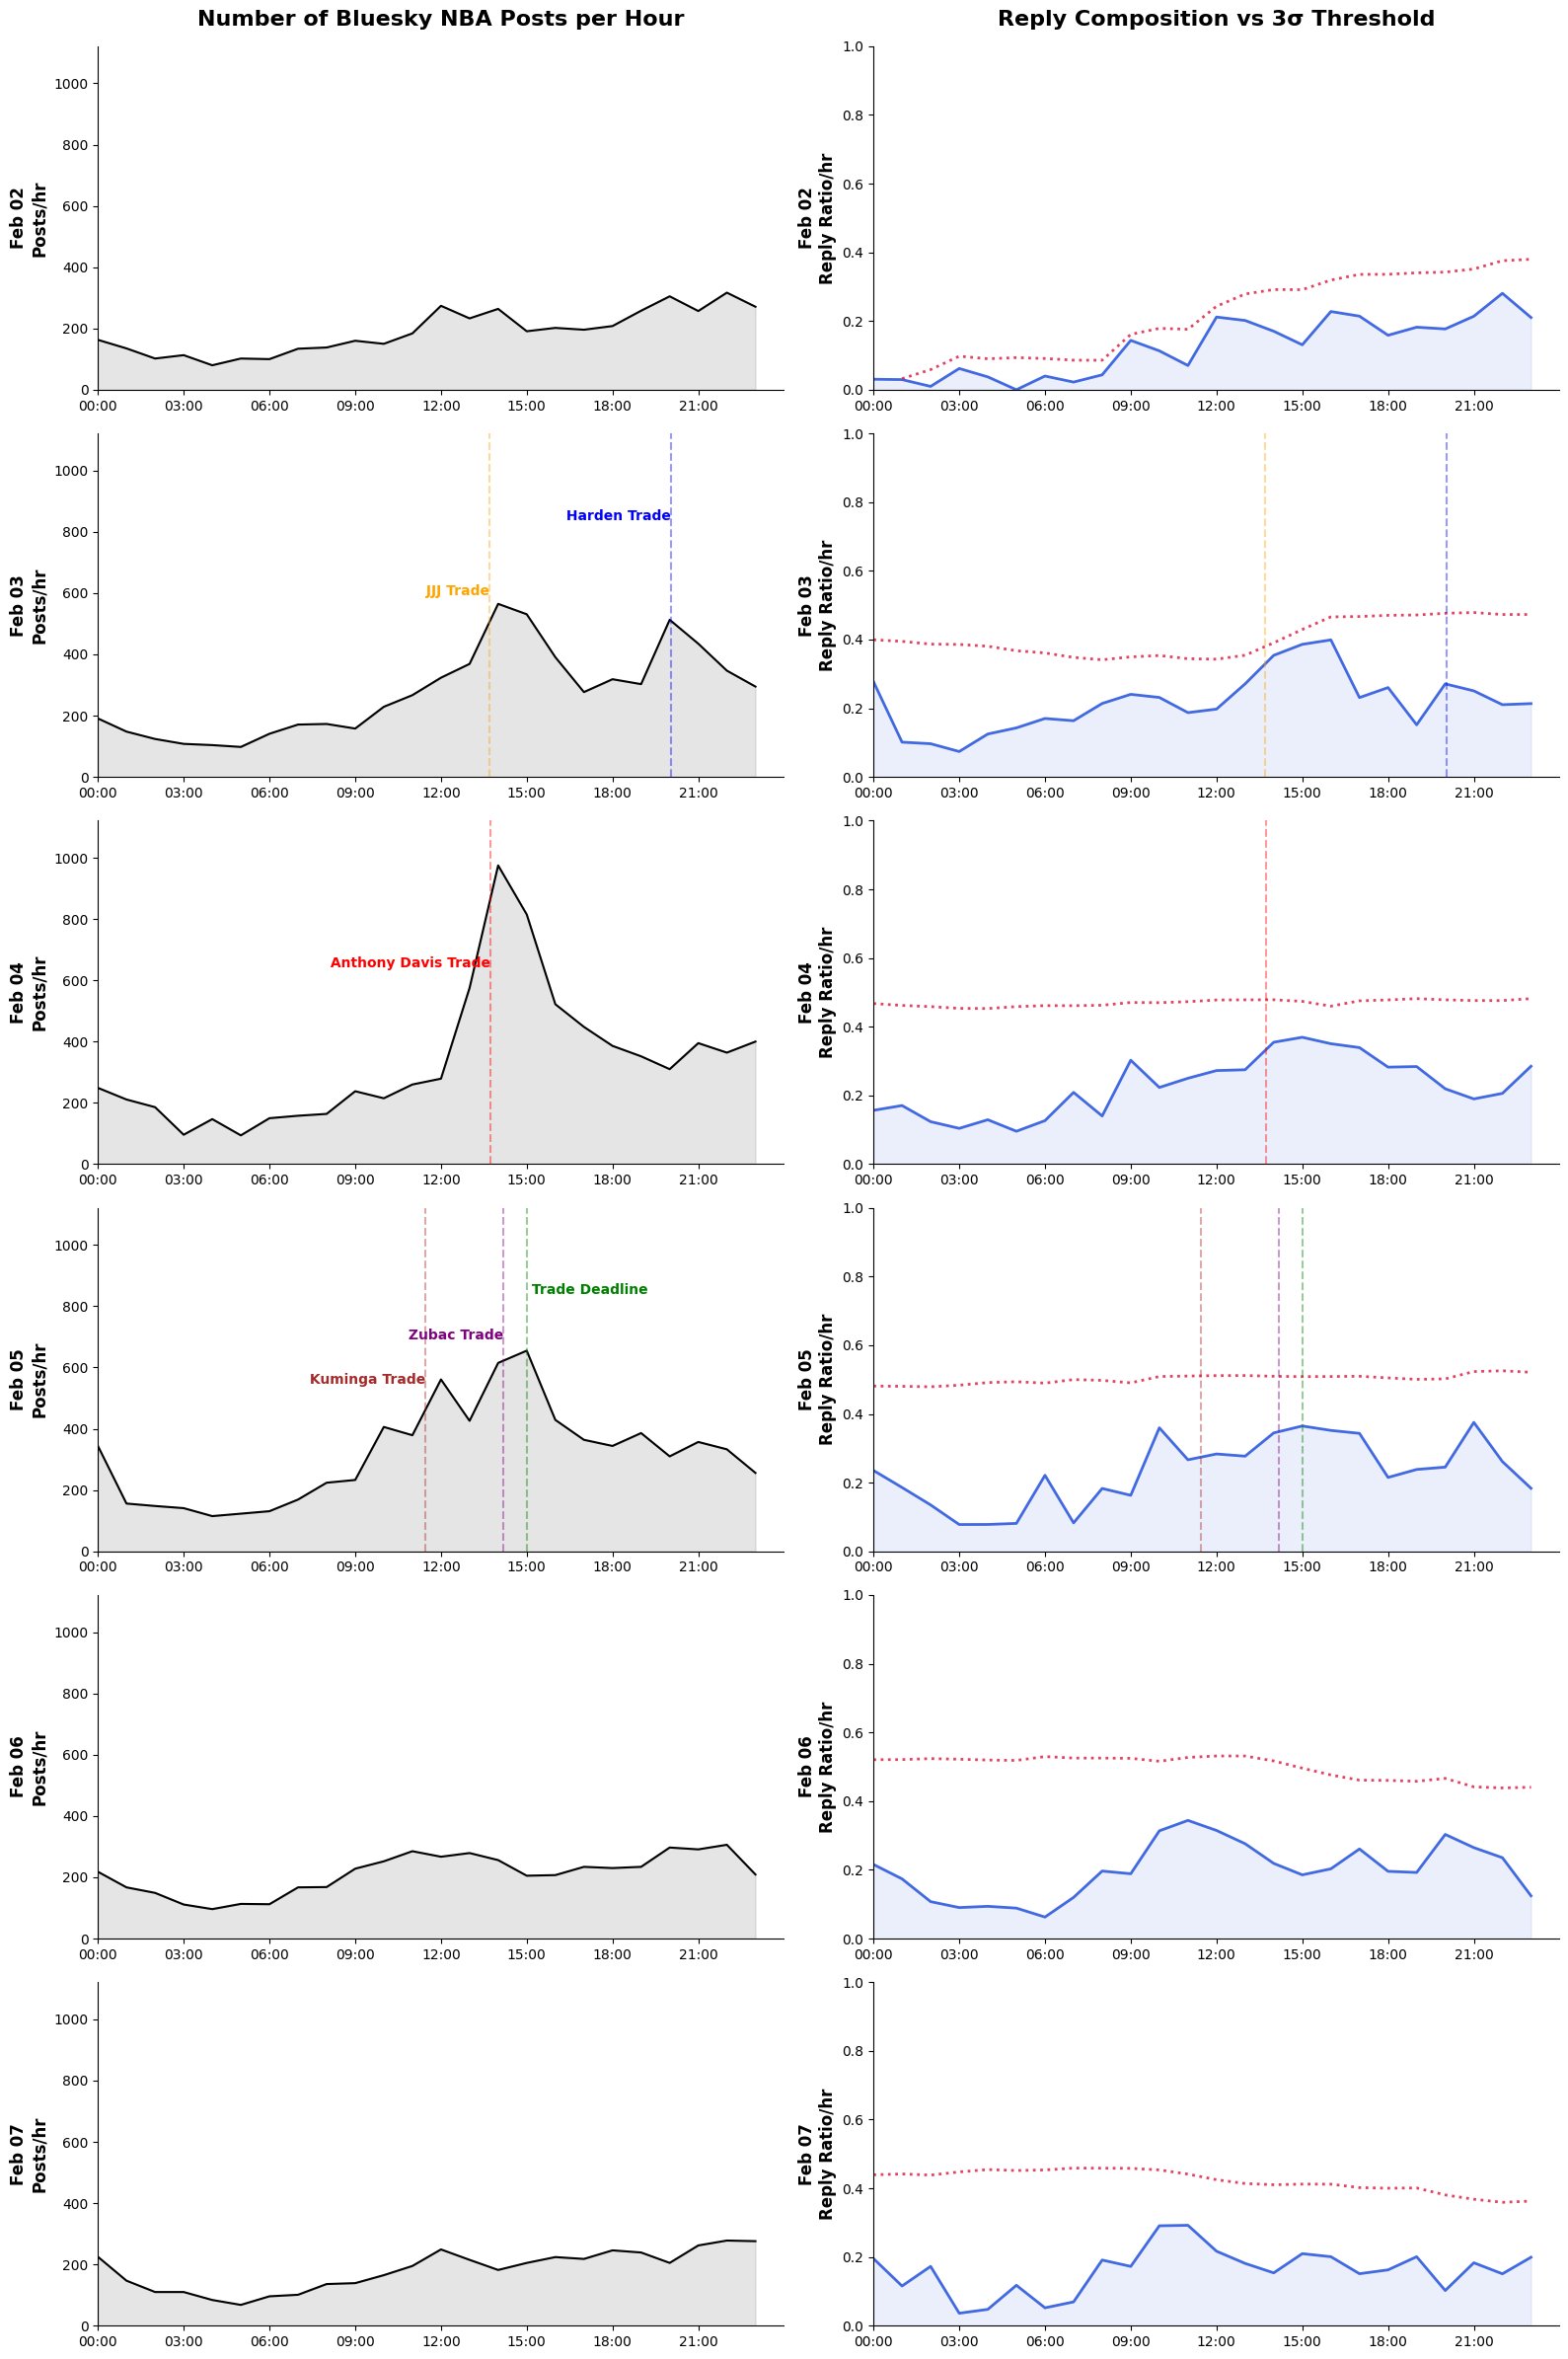

In [70]:
#Number of posts per hour vs reply ratio
#Reply ratio = # of replies / (# of replies + # of original posts)
import matplotlib.dates as mdates

#Events
events = [
    {"name": "JJJ Trade", "time": "2026-02-03 13:41", "color": "orange", "y_pct": 0.6, "ha": "right"},
    {"name": "Harden Trade", "time": "2026-02-03 20:03", "color": "blue", "y_pct": 0.85, "ha": "right"},
    {"name": "Anthony Davis Trade", "time": "2026-02-04 13:44", "color": "red", "y_pct": 0.65, "ha": "right"},
    {"name": "Kuminga Trade", "time": "2026-02-05 11:28", "color": "brown", "y_pct": 0.55, "ha": "right"},
    {"name": "Zubac Trade", "time": "2026-02-05 14:11", "color": "purple", "y_pct": 0.7, "ha": "right"},
    {"name": "Trade Deadline", "time": "2026-02-05 15:00", "color": "green", "y_pct": 0.85, "ha": "left"},
]

hourly_counts = nodes.groupby([pd.Grouper(key='Date_ET', freq='h'), 'post_type']).size().unstack(fill_value=0)

for col in ['reply', 'original_post']:
    if col not in hourly_counts: hourly_counts[col] = 0

hourly_counts['Total'] = hourly_counts['reply'] + hourly_counts['original_post']
hourly_counts['Reply_Pct'] = hourly_counts['reply'] / hourly_counts['Total'].replace(0, 1)

# Stats for 3-Sigma line for reply ratio
window = 24
rolling_mean = hourly_counts['Reply_Pct'].rolling(window=window, min_periods=1).mean()
rolling_std = hourly_counts['Reply_Pct'].rolling(window=window, min_periods=1).std()
hourly_counts['Sigma_3_Line'] = rolling_mean + (3 * rolling_std)

target_days = [d for d in sorted(nodes['Date_ET'].dt.date.unique())
               if pd.Timestamp('2026-02-02').date() <= d <= pd.Timestamp('2026-02-07').date()]

# We use pd.Series() to allow the use of .isin() on the date array
is_target_day = pd.Series(hourly_counts.index.date).isin(target_days).values
global_max_vol = hourly_counts.loc[is_target_day, 'Total'].max()

#Plotting
fig, axes = plt.subplots(len(target_days), 2, figsize=(16, 4 * len(target_days)),
                       gridspec_kw={'width_ratios': [1, 1]}, sharex=False)

for i, day in enumerate(target_days):
    day_data = hourly_counts[hourly_counts.index.date == day]
    ax_vol, ax_rat = axes[i, 0], axes[i, 1]
    day_start, day_end = pd.Timestamp(day), pd.Timestamp(day) + pd.Timedelta(hours=23, minutes=59)

    # --- Left Column: Volume (Synced Y-Axis) ---
    ax_vol.fill_between(day_data.index, day_data['Total'], color='black', alpha=0.1)
    ax_vol.plot(day_data.index, day_data['Total'], color='black', lw=1.5)
    ax_vol.set_ylim(0, global_max_vol * 1.15)
    ax_vol.set_ylabel(f"{day.strftime('%b %d')}\nPosts/hr", fontweight='bold', fontsize=12)
    ax_vol.set_xlim(day_start, day_end)
    ax_vol.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    # --- Right Column: Reply % ---
    ax_rat.plot(day_data.index, day_data['Reply_Pct'], color='royalblue', lw=2)
    ax_rat.fill_between(day_data.index, day_data['Reply_Pct'], color='royalblue', alpha=0.1)
    ax_rat.plot(day_data.index, day_data['Sigma_3_Line'], color='crimson', linestyle=':', lw=2, alpha=0.8)
    ax_rat.set_ylim(0, 1.0)
    ax_rat.set_ylabel(f"{day.strftime('%b %d')}\nReply Ratio/hr", fontweight='bold', fontsize=12)
    ax_rat.set_xlim(day_start, day_end)
    ax_rat.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

    # --- Annotations ---
    for ev in events:
        ev_ts = pd.Timestamp(ev['time'])
        if ev_ts.date() == day:
            for ax in [ax_vol, ax_rat]:
                ax.axvline(ev_ts, color=ev['color'], ls='--', alpha=0.4)

            y_pos = global_max_vol * ev['y_pct']
            ax_vol.text(ev_ts, y_pos, f" {ev['name']}",
                        color=ev['color'], fontweight='bold', fontsize=10,
                        ha=ev['ha'], va='bottom', clip_on=False)

axes[0, 0].set_title("Number of Bluesky NBA Posts per Hour", fontsize=16, pad=15, fontweight='bold')
axes[0, 1].set_title("Reply Composition vs 3σ Threshold", fontsize=16, pad=15, fontweight='bold')

for ax in axes.flatten():
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Table with network metrics on each day, number of tweets, number of replies, number of trades, and 3 highest in degree nodes.

In [57]:
nodes['Date_ET'].dt.date

,Date_ET
0,2026-02-02
1,2026-02-02
2,2026-02-02
3,2026-02-02
4,2026-02-02
...,...
36434,2026-02-07
36435,2026-02-07
36436,2026-02-07
36437,2026-02-07


In [58]:
#Adds a Date column
nodes['Date_Only'] = nodes['Date_ET'].dt.date

#Merge weighted_edges with nodes_df to get dated_weighted_edges
dated_weighted_edges = weighted_edges.merge(
    nodes[['User_Handle', 'Date_Only']],
    left_on='Source_Handle',
    right_on='User_Handle',
    how='left'
).drop(columns=['User_Handle'])

daily_metrics = []

#Get a sorted list of days
unique_dates = sorted(nodes['Date_Only'].unique())

#Loop through each day
for current_date in unique_dates[:6]:
    #Only include nodes for the current day
    daily_nodes_df = nodes[nodes['Date_Only'] == current_date]

    #Filter dated_weighted_edges for daily_edges
    daily_edges = dated_weighted_edges[dated_weighted_edges['Date_Only'] == current_date]

    # e. Initialize default values for centralization metrics and top in-degree nodes
    in_deg_centralization = 0.0
    out_deg_centralization = 0.0
    between_centralization = 0.0
    closeness_centralization = 0.0
    eigen_centralization = 0.0
    pagerank_centralization = 0.0
    top_3_indegree_nodes = "N/A"

    #Check if daily_edges is not empty
    if daily_edges.empty:
        daily_metrics.append({
            "Date": current_date,
            "Total_Posts": len(G_daily.nodes),
            "Replies": len(G_daily.edges),
            "Density": nx.density(G_daily),
            "In_Degree_Centralization": in_deg_centralization,
            "Out_Degree_Centralization": out_deg_centralization,
            "Betweenness_Centralization": between_centralization,
            "Closeness_Centralization": closeness_centralization,
            "Eigenvector_Centralization": eigen_centralization,
            "Pagerank_Centralization": pagerank_centralization,
            "Top_3_In_Degree_Nodes": top_3_indegree_nodes
        })
        continue

    #Create a new directed NetworkX graph, G_daily
    G_daily = nx.DiGraph()
    for _, row in daily_edges.iterrows():
        G_daily.add_edge(
            row['Source_Handle'],
            row['Target_Handle'],
            weight=row['Weight']
        )

    #Check if G_daily contains at least two nodes
    if G_daily.number_of_nodes() < 2:
        daily_metrics.append({
            "Date": current_date,
            "Total_Posts": len(G_daily.nodes),
            "Replies": len(G_daily.edges),
            "Density": nx.density(G_daily),
            "In_Degree_Centralization": in_deg_centralization,
            "Out_Degree_Centralization": out_deg_centralization,
            "Betweenness_Centralization": between_centralization,
            "Closeness_Centralization": closeness_centralization,
            "Eigenvector_Centralization": eigen_centralization,
            "Pagerank_Centralization": pagerank_centralization,
            "Top_3_In_Degree_Nodes": top_3_indegree_nodes
        })
        continue

    #Calculate node-level centralities for G_daily
    in_degree_centralities_daily = nx.in_degree_centrality(G_daily)
    out_degree_centralities_daily = nx.out_degree_centrality(G_daily)
    betweenness_centralities_daily = nx.betweenness_centrality(G_daily)
    closeness_centralities_daily = nx.closeness_centrality(G_daily)
    eigenvector_centralities_daily = nx.eigenvector_centrality(G_daily, max_iter=1000, tol=1.0e-6)
    pagerank_centralities_daily = nx.pagerank(G_daily, alpha = 0.85)


    #Calculate the global centralization for each centrality measure
    N_daily = G_daily.number_of_nodes()
    in_deg_centralization = get_centralization(in_degree_centralities_daily, N_daily, 'degree')
    out_deg_centralization = get_centralization(out_degree_centralities_daily, N_daily, 'degree')
    between_centralization = get_centralization(betweenness_centralities_daily, N_daily, 'betweenness')
    closeness_centralization = get_centralization(closeness_centralities_daily, N_daily, 'closeness')
    eigen_centralization = get_centralization(eigenvector_centralities_daily, N_daily, 'degree')
    pagerank_centralization = get_centralization(pagerank_centralities_daily, N_daily, 'pagerank')

    #Identify the top 3 nodes by in-degree for G_daily
    daily_in_degrees = dict(G_daily.in_degree())
    sorted_daily_in_degrees = sorted(daily_in_degrees.items(), key=lambda item: item[1], reverse=True)
    top_3_nodes_list = []
    for node, degree in sorted_daily_in_degrees[:3]:
        top_3_nodes_list.append(f"{node} ({degree})")
    top_3_indegree_nodes = ", ".join(top_3_nodes_list) if top_3_nodes_list else "N/A"

    #Store all calculated metrics
    daily_metrics.append({
        "Date": current_date,
        "Total_Posts/Nodes": len(G_daily.nodes),
        "Replies/Edges": len(G_daily.edges),
        # Numerical centralization scores rounded to 4 decimal places
        "Density": round(nx.density(G_daily), 4),
        "In_Degree_Centralization": round(in_deg_centralization, 4),
        "Out_Degree_Centralization": round(out_deg_centralization, 4),
        "Betweenness_Centralization": round(between_centralization, 4),
        "Closeness_Centralization": round(closeness_centralization, 4),
        "Eigenvector_Centralization": round(eigen_centralization, 4),
        "Pagerank_Centralization": round(pagerank_centralization, 4),
        "Top_3_In_Degree_Nodes": top_3_indegree_nodes
    })

In [59]:
daily_stats_df = pd.DataFrame(daily_metrics)
daily_stats_df.head(10)

,Date,Total_Posts/Nodes,Replies/Edges,Density,In_Degree_Centralization,Out_Degree_Centralization,Betweenness_Centralization,Closeness_Centralization,Eigenvector_Centralization,Pagerank_Centralization,Top_3_In_Degree_Nodes
0,2026-02-02,1171,1484,0.0011,0.0417,0.0280,0.0170,0.0390,0.6323,0.0175,"markjacob.bsky.social (50), shamsbot.bsky.social (36), theathletic.com (28)"
1,2026-02-03,1997,2823,0.0007,0.0645,0.0163,0.0262,0.0824,0.3373,0.0174,"shamsbot.bsky.social (130), keithsmithnba.bsky.social (51), nba.com (47)"
2,2026-02-04,2363,3308,0.0006,0.0663,0.0138,0.0231,0.0929,0.3865,0.0171,"shamsbot.bsky.social (158), theathletic.com (111), chrislhayes.bsky.social (83)"
3,2026-02-05,2222,3207,0.0006,0.0606,0.0147,0.0292,0.0788,0.3981,0.0153,"shamsbot.bsky.social (136), keithsmithnba.bsky.social (67), chrislhayes.bsky.social (57)"
4,2026-02-06,1587,2073,0.0008,0.0320,0.0206,0.0221,0.0438,0.3422,0.0174,"shamsbot.bsky.social (52), parkermolloy.com (43), washingtonstatestandard.com (34)"
5,2026-02-07,1297,1661,0.0010,0.0338,0.0253,0.0227,0.0495,0.3823,0.0381,"shamsbot.bsky.social (45), nba.com (34), davidbix.bsky.social (31)"


In [60]:
num_trades = [0, 2, 4, 17, 0, 0]
daily_stats_df['Trades'] = num_trades

In [61]:
print(daily_stats_df.to_markdown(index=False))

| Date       |   Total_Posts/Nodes |   Replies/Edges |   Density |   In_Degree_Centralization |   Out_Degree_Centralization |   Betweenness_Centralization |   Closeness_Centralization |   Eigenvector_Centralization |   Pagerank_Centralization | Top_3_In_Degree_Nodes                                                                    |   Trades |
|:-----------|--------------------:|----------------:|----------:|---------------------------:|----------------------------:|-----------------------------:|---------------------------:|-----------------------------:|--------------------------:|:-----------------------------------------------------------------------------------------|---------:|
| 2026-02-02 |                1171 |            1484 |    0.0011 |                     0.0417 |                      0.028  |                       0.017  |                     0.039  |                       0.6323 |                    0.0175 | markjacob.bsky.social (50), shamsbot.bsky.social (36), theath

In [62]:
import pandas as pd

# Create a date range from '2026-02-02' to '2026-02-07' (inclusive)
date_range = pd.date_range(start='2026-02-02', end='2026-02-07').date

# Initialize an empty dictionary to store daily edges data
daily_edges_data = {}

# Iterate through each date in the defined date range
for current_date in date_range:
    # Filter the dated_weighted_edges DataFrame for the current date
    daily_edges_df = dated_weighted_edges[dated_weighted_edges['Date_Only'] == current_date]

    # Store the filtered DataFrame in the dictionary
    daily_edges_data[current_date] = daily_edges_df

print(f"Created daily_edges_data dictionary with {len(daily_edges_data)} entries.")
print("Keys (Dates) in dictionary:", list(daily_edges_data.keys()))
print("Shape of edges for 2026-02-02:", daily_edges_data[pd.to_datetime('2026-02-02').date()].shape)

Created daily_edges_data dictionary with 6 entries.
Keys (Dates) in dictionary: [datetime.date(2026, 2, 2), datetime.date(2026, 2, 3), datetime.date(2026, 2, 4), datetime.date(2026, 2, 5), datetime.date(2026, 2, 6), datetime.date(2026, 2, 7)]
Shape of edges for 2026-02-02: (4132, 6)


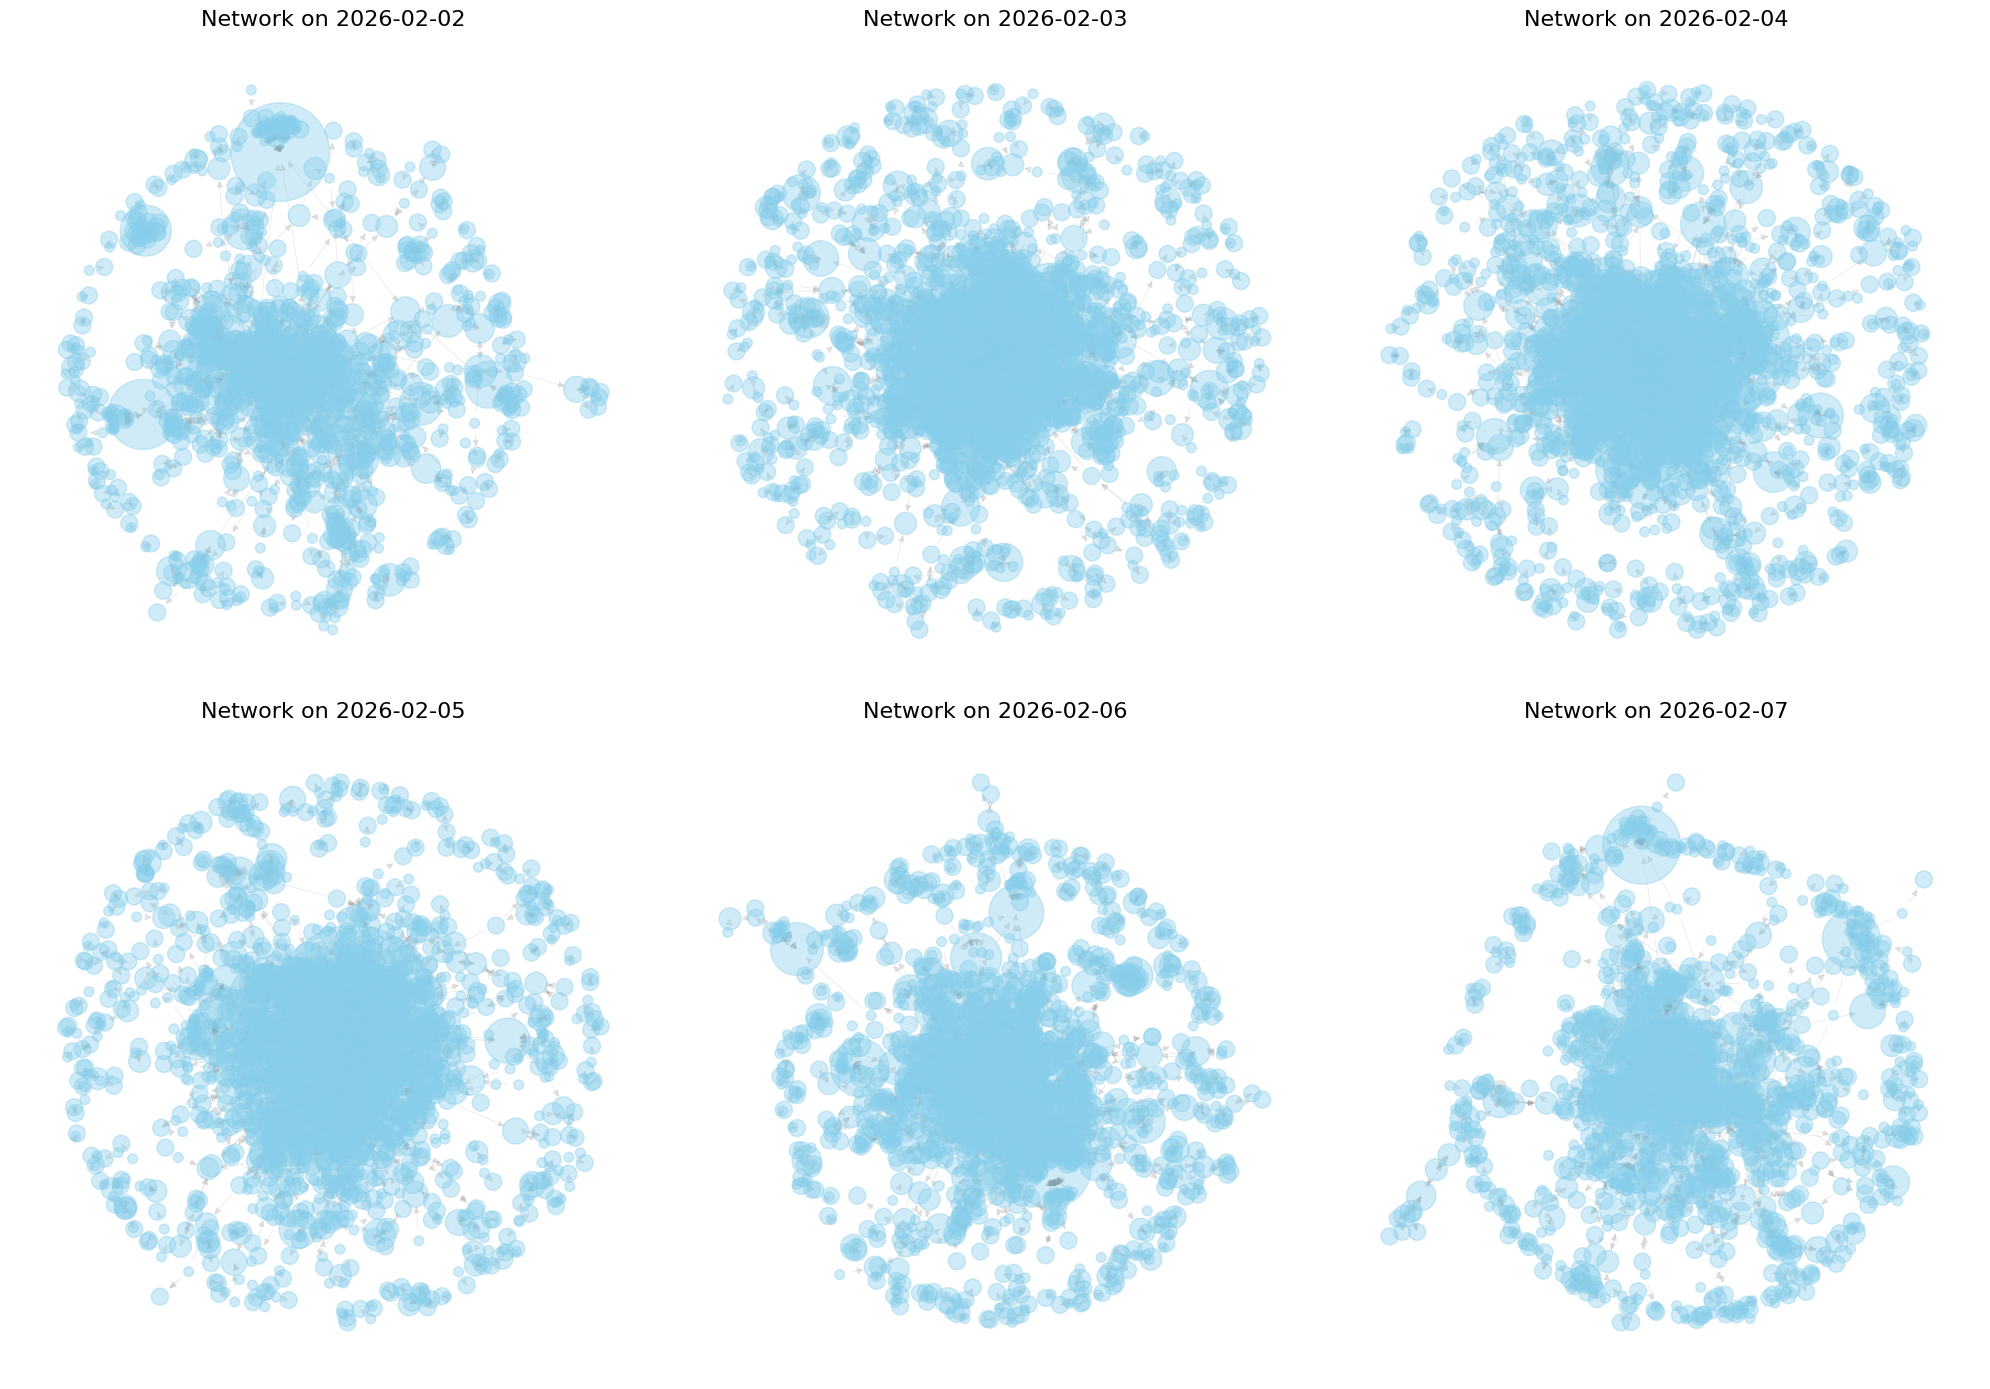

In [63]:
#Network on each day

fig, axes = plt.subplots(2, 3, figsize=(20, 14)) # Adjust figsize as needed
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

#Iterate through the daily_edges_data dictionary
for i, (current_date, daily_edges_df) in enumerate(daily_edges_data.items()):
    ax = axes[i] # Get the current subplot axis

    #Create an empty directed graph using nx.DiGraph()
    G_daily = nx.DiGraph()

    #Populate the graph with nodes and edges from the current day's daily_edges_df
    #Ensure to include the 'Weight' attribute for each edge.
    if not daily_edges_df.empty:
        for _, row in daily_edges_df.iterrows():
            G_daily.add_edge(
                row['Source_Handle'],
                row['Target_Handle'],
                weight=row['Weight']
            )

    # Only proceed with drawing if the graph has nodes
    if G_daily.number_of_nodes() > 0:
        #Calculate the in-degree for each node in the daily graph.
        #Scale these in-degree values to determine appropriate node_sizes.
        node_sizes = [G_daily.in_degree(n) * 100 + 50 for n in G_daily.nodes()]
        #Extract the 'Weight' attribute from each edge to determine edge_widths.
        edge_widths = [G_daily[u][v]['weight'] * 0.5 for u, v in G_daily.edges()]

        #Draw the network
        pos = nx.spring_layout(G_daily, k=0.5, seed=42)
        nx.draw_networkx_nodes(G_daily, pos, node_size=node_sizes, node_color='skyblue', alpha=0.4, ax=ax)
        nx.draw_networkx_edges(G_daily, pos, width=edge_widths, alpha=0.2, edge_color='gray', arrows=True, ax=ax)

    #Set the title of the current subplot to the corresponding date.
    ax.set_title(f'Network on {current_date.strftime("%Y-%m-%d")}', fontsize=16)

    #Turn off the axis for the current subplot.
    ax.axis('off')

plt.tight_layout()
plt.show()


In [64]:
#Extract core nodes (degree >= 5)
daily_core_graphs = {}

#Iterate through each date and its corresponding daily_edges_df
for current_date, daily_edges_df in daily_edges_data.items():
    #Create a graph
    G_daily = nx.DiGraph()

    if not daily_edges_df.empty:
        for _, row in daily_edges_df.iterrows():
            G_daily.add_edge(
                row['Source_Handle'],
                row['Target_Handle'],
                weight=row['Weight']
            )

    # Only proceed if the graph has nodes
    if G_daily.number_of_nodes() > 0:
        #Calculate the in-degree for all nodes in G_daily
        degrees = dict(G_daily.degree())

        #Identify 'core' nodes as those with a degree of 5 or more
        core_nodes = [node for node, degree in degrees.items() if degree >= 5]

        #Create a subgraph, G_core_daily, from G_daily consisting only of these identified core_nodes
        G_core_daily = G_daily.subgraph(core_nodes).copy()

        #Store G_core_daily in the daily_core_graphs dictionary
        daily_core_graphs[current_date] = G_core_daily
    else:
        # If G_daily is empty, store an empty graph or handle as needed
        daily_core_graphs[current_date] = nx.DiGraph()

print(f"Created daily_core_graphs dictionary with {len(daily_core_graphs)} entries.")

Created daily_core_graphs dictionary with 6 entries.


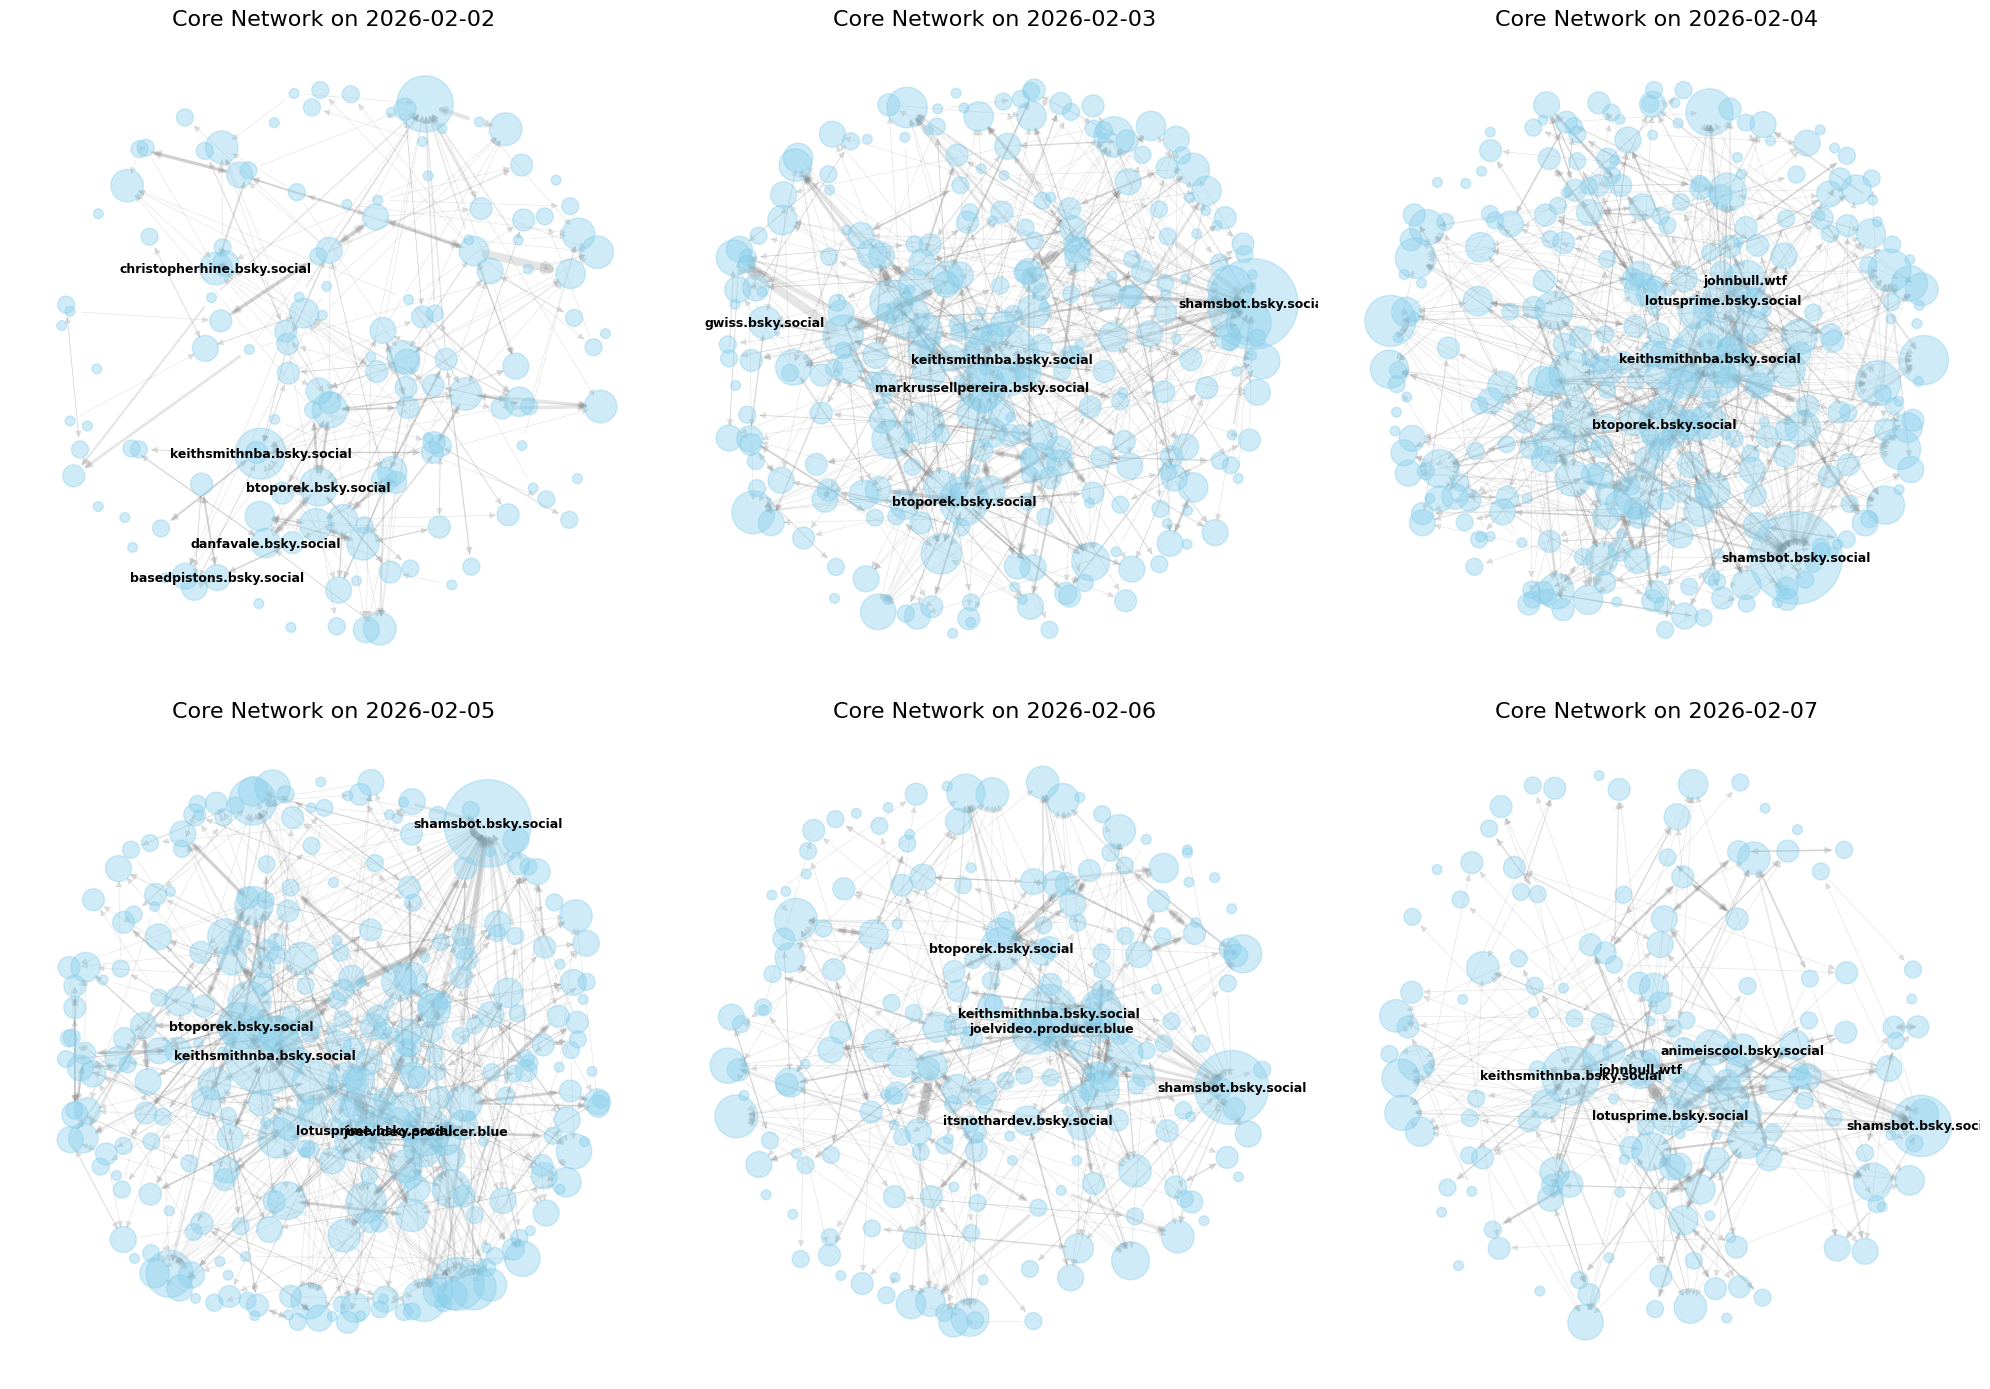

In [65]:
#Create network of core on each day
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
axes = axes.flatten()

#Loop through daily core graphs
for i, (current_date, G_core_daily) in enumerate(daily_core_graphs.items()):
    ax = axes[i]
    if G_core_daily.number_of_nodes() > 0:
        pos = nx.spring_layout(G_core_daily, k=0.5, seed=42)

        #Scale nodes by in-degree
        node_sizes = [G_core_daily.in_degree(n) * 100 + 50 for n in G_core_daily.nodes()]
        #Scale edges by weight
        edge_widths = [G_core_daily[u][v]['weight'] * 0.5 for u, v in G_core_daily.edges()]

        #Draw nodes
        nx.draw_networkx_nodes(G_core_daily, pos, node_size=node_sizes,
                               node_color='skyblue', alpha=0.4, ax=ax)

        #Draw edges
        nx.draw_networkx_edges(G_core_daily, pos, width=edge_widths,
            alpha=0.2, edge_color='gray', arrows=True, ax=ax)


        #Identify Top Influencers for Labels - top 5 influencers with the higest pagerank
        page_cent = nx.pagerank(G_core_daily, alpha = 0.85)
        top_nodes = sorted(page_cent.items(), key=lambda x: x[1], reverse=True)[:5]
        labels = {node: node for node, val in top_nodes}

        # Create label dictionary
        labels = {node: node for node, val in top_nodes}

        # Draw labels
        nx.draw_networkx_labels(G_core_daily, pos, labels=labels, font_size=9,
                                font_weight='bold', ax=ax)


    ax.set_title(
        f'Core Network on {current_date.strftime("%Y-%m-%d")}',
        fontsize=16
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

In [66]:
#Comparing basic network metrics for entire network vs the core
daily_core_network_metrics = []

for current_date in unique_dates[:6]:
    G_daily = nx.DiGraph()
    daily_edges_df = daily_edges_data.get(current_date)
    if daily_edges_df is not None and not daily_edges_df.empty:
        for _, row in daily_edges_df.iterrows():
            G_daily.add_edge(
                row['Source_Handle'],
                row['Target_Handle'],
                weight=row['Weight']
            )

    # Metrics for the entire daily network
    num_nodes_daily = G_daily.number_of_nodes()
    num_edges_daily = G_daily.number_of_edges()
    density_daily = nx.density(G_daily) if num_nodes_daily > 1 else 0.0

    # Metrics for the daily core network
    G_core_daily = daily_core_graphs.get(current_date)
    num_nodes_core = G_core_daily.number_of_nodes() if G_core_daily else 0
    num_edges_core = G_core_daily.number_of_edges() if G_core_daily else 0
    density_core = nx.density(G_core_daily) if num_nodes_core > 1 else 0.0

    daily_core_network_metrics.append({
        "Date": current_date,
        "Total_Network_Nodes": num_nodes_daily,
        "Total_Network_Edges": num_edges_daily,
        "Total_Network_Density": round(density_daily, 4),
        "Core_Network_Nodes": num_nodes_core,
        "Core_Network_Edges": num_edges_core,
        "Core_Network_Density": round(density_core, 4)
    })

daily_network_summary_df = pd.DataFrame(daily_core_network_metrics)
display(daily_network_summary_df)


,Date,Total_Network_Nodes,Total_Network_Edges,Total_Network_Density,Core_Network_Nodes,Core_Network_Edges,Core_Network_Density
0,2026-02-02,1171,1484,0.0011,138,268,0.0142
1,2026-02-03,1997,2823,0.0007,278,662,0.0086
2,2026-02-04,2363,3308,0.0006,308,756,0.0080
3,2026-02-05,2222,3207,0.0006,301,773,0.0086
4,2026-02-06,1587,2073,0.0008,207,450,0.0106
5,2026-02-07,1297,1661,0.0010,155,352,0.0147
